## RC and RL Networks Response

In [5]:
import requests as req, os

URL = "https://raw.githubusercontent.com/mit-acl/16_06_Class/main/"
File = ["basic_material.py","control_materials.py","read_csv_data.py"]

if not os.path.isfile(File[0]):
    print('Basic files not found - downloading them')
    for dfile in File:
        if not os.path.isfile(dfile):
            print("Downloading "+dfile)
            res = req.get(URL+dfile)
            file = open(dfile, 'w')
            file.write(res.text)
            file.close()

print('Basic file found')
%run basic_material.py

try:
    import lcapy
except ModuleNotFoundError:
    print("Could not find lcapy - installing")
    !sudo apt install texlive-latex-recommended # takes about 30 sec
    !sudo apt-get install texlive-latex-extra --no-install-recommends # 10 sec
    !sudo apt install imagemagick # 10 sec
    !pip install sympy==1.10.1
    !pip install lcapy # takes 5 sec
    !pip install pdflatex # takes about 5 sec
    print("Will need to restart the Kernel")

from lcapy import Circuit, j, omega, s, exp
from lcapy import R, C, L, symbol

from sympy import N
from control.matlab import tf

from control_materials import *
from read_csv_data import *

R1 = 10e3
C1 = 10e-6

Basic file found
Running Python: 3.8.17
Running Sympy: 1.12rc1
Control Package Found


# Analog 3 pole for lab

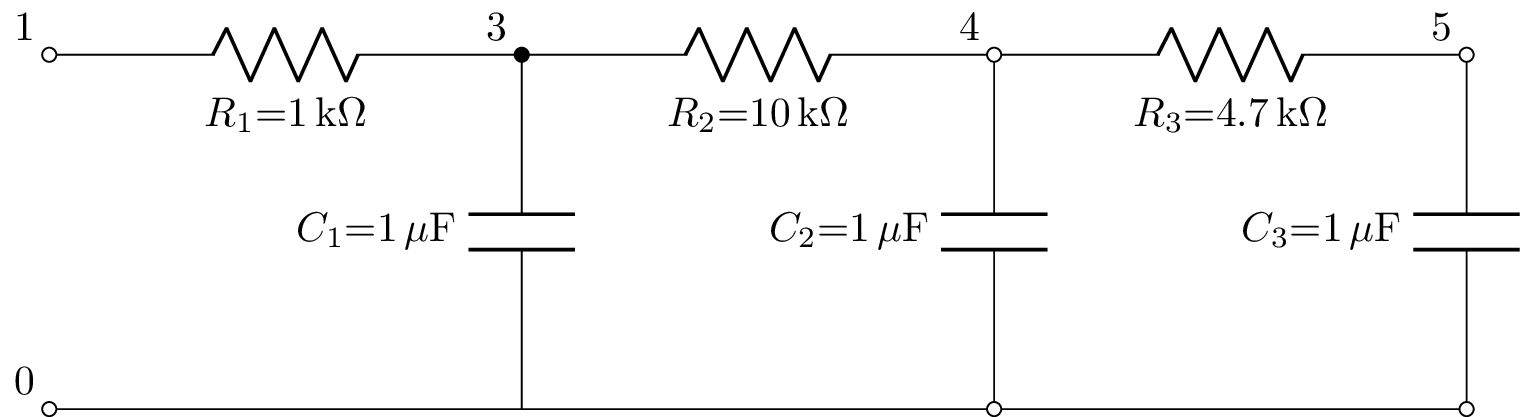

Poles (Hz) -177.19, -6.45, -75.07
Zeros (Hz) -33.86


TransferFunction(array([ 100000.000,  21276595.745]), array([   1.000,  1625.532,  589361.702,  21276595.745]))

In [6]:
cct1rc = Circuit("""
P1 1 0; down=1.5
R1 1 3 R1; right=2
C1 3 0_3 C; down=1.5
R2 3 4 R2; right=2
C2 4 0_4 C; down=1.5
R3 4 5 R3; right=2
C3 5 0_5 C; down=1.5
W4 0 0_3; right=2
W5 0_3 0_4; right=2
W6 0_4 0_5; right=2
P5 5 0_5; down=1.5
P4 4 0_4; down=1.5
""")

Cap = 1e-6 # 105
Res = [1e3,10e3,4.7e3]

cct1 = cct1rc.subs({'R1': Res[0], 'R2': Res[1], 'R3': Res[2], 'C':Cap})
cct1.draw()

Hl = cct1.P1.transfer('P4') # with zero
#Hl = cct1.P1.transfer('P5')
lpoles = N(Hl.poles(1)).fval
lzeros = N(Hl.zeros(1)).fval
print("Poles (Hz) "+', '.join("{:3.2f}".format(p/2/np.pi) for p in lpoles))
print("Zeros (Hz) "+', '.join("{:3.2f}".format(z/2/np.pi) for z in lzeros))

Num,Den = N(Hl).as_N_D()
NN = [Num.coeffs()[x].fval for x in range(len(lzeros)+1)]
DD = [Den.coeffs()[x].fval for x in range(len(lpoles)+1)]
G = tf(NN,DD)
G

In [7]:
Cap = 1e-6
pp = [1/xx for xx in np.array([Cap, Cap, Cap])*np.array(Res)]
print("Individual Poles (Hz) "+', '.join("{:3.2f}".format(p/2/np.pi) for p in pp))

Individual Poles (Hz) 159.15, 15.92, 33.86


In [8]:
Gapprox4 = tf([1],[(Res[0]*Cap), 1])*tf([1],[(Res[1]*Cap), 1])
Gapprox5 = tf([1],[(Res[0]*Cap), 1])*tf([1],[(Res[1]*Cap), 1])*tf([1],[(Res[2]*Cap/10), 1])

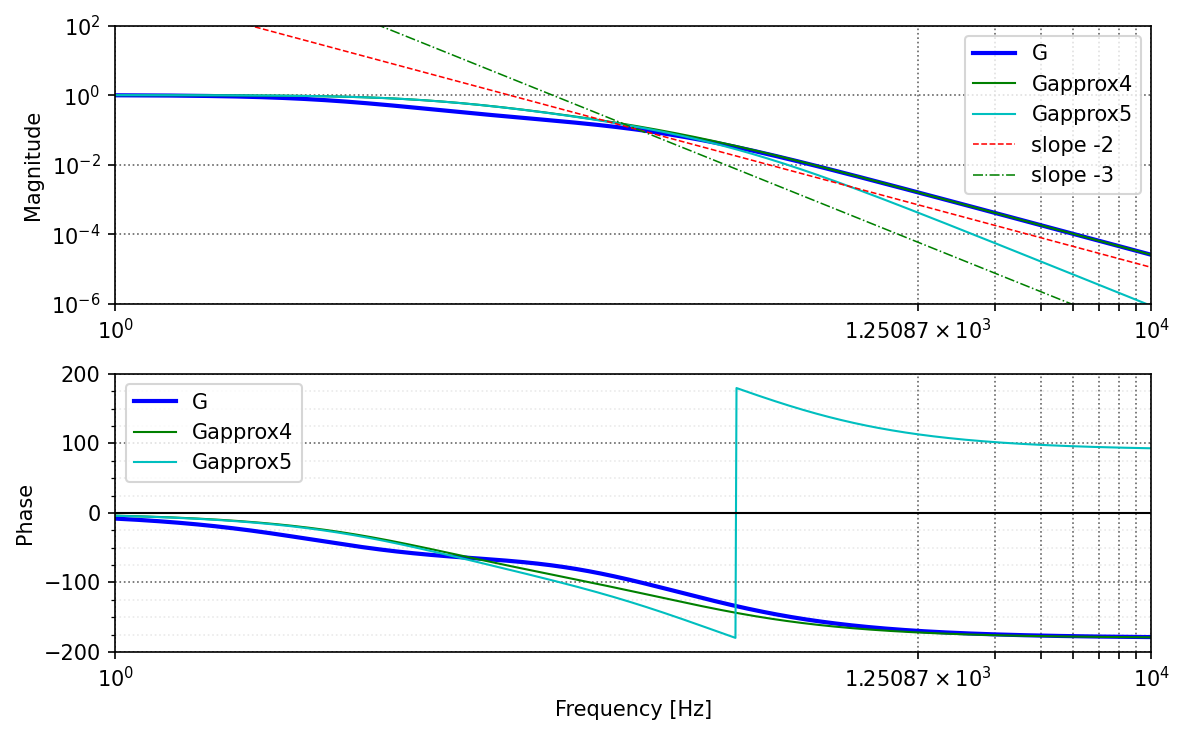

In [9]:
fv = logspace(0, 4, 1000)
w = fv*2*np.pi
Gf = G(complex(0,1)*w)
Gapproxf4 = Gapprox4(complex(0,1)*w)
Gapproxf5 = Gapprox5(complex(0,1)*w)

mag_bw = 0.1
fc = find_wc(w,Gf,mag_bw)/2/np.pi

fig, ax = plt.subplots(2,1,figsize=(8, 5),dpi=150)
ax[0].loglog(fv,np.abs(Gf),color='b',ls='-',label='G')
ax[0].loglog(fv,np.abs(Gapproxf4),color='g',ls='-',label='Gapprox4',lw=1)
ax[0].loglog(fv,np.abs(Gapproxf5),color='c',ls='-',label='Gapprox5',lw=1)
ax[0].loglog(fv,mag_bw*(fc/fv)**2,color='r',ls='--',label='slope -2',lw=0.75)
ax[0].loglog(fv,mag_bw*(fc/fv)**3,color='g',ls='-.',label='slope -3',lw=0.75)
#ax[0].axhline(y=mag_bw,c='m',ls='--')
ax[1].semilogx(fv,np.angle(Gf)*r2d,color='b',ls='-',label='G')
ax[1].semilogx(fv,np.angle(Gapproxf4)*r2d,color='g',ls='-',label='Gapprox4',lw=1)
ax[1].semilogx(fv,np.angle(Gapproxf5)*r2d,color='c',ls='-',label='Gapprox5',lw=1)
ax[0].set_ylim([1e-6,1e2])
ax[1].set_ylim([-200,200])
#ax[0].set_xlim([.1,10])
ax[0].set_ylabel("Magnitude")
ax[1].set_ylabel("Phase")
ax[1].set_xlabel("Frequency [Hz]")
ax[0].legend()
ax[1].legend()
nicegrid(ax)
#savefig('figs/Analog_Lead.pdf',dpi=600)

# Network Example 1

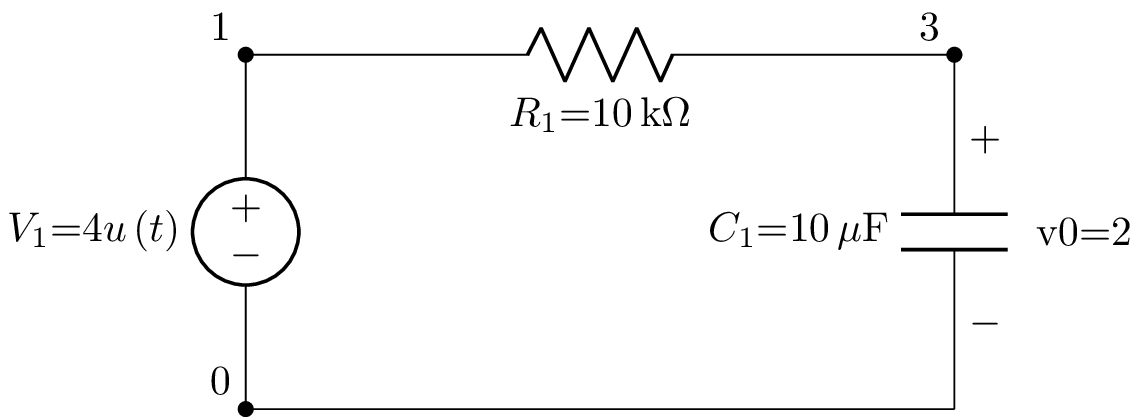

In [10]:
cct1rc = Circuit("""
V1 1 0 {4*u(t)}; down=1.5
R1 1 3 R; right=3
C1 3 0_3 C 2; down=1.5
W4 0 0_3; right=3
""")

cct1 = cct1rc.subs({'R': R1, 'C':C1})
cct1.draw()


In [11]:
t = np.linspace(0, 1, 1000)
vc1 = cct1.C1.v.evaluate(t)
ic1 = cct1.C1.i.evaluate(t)
vr1 = cct1.R1.v.evaluate(t)

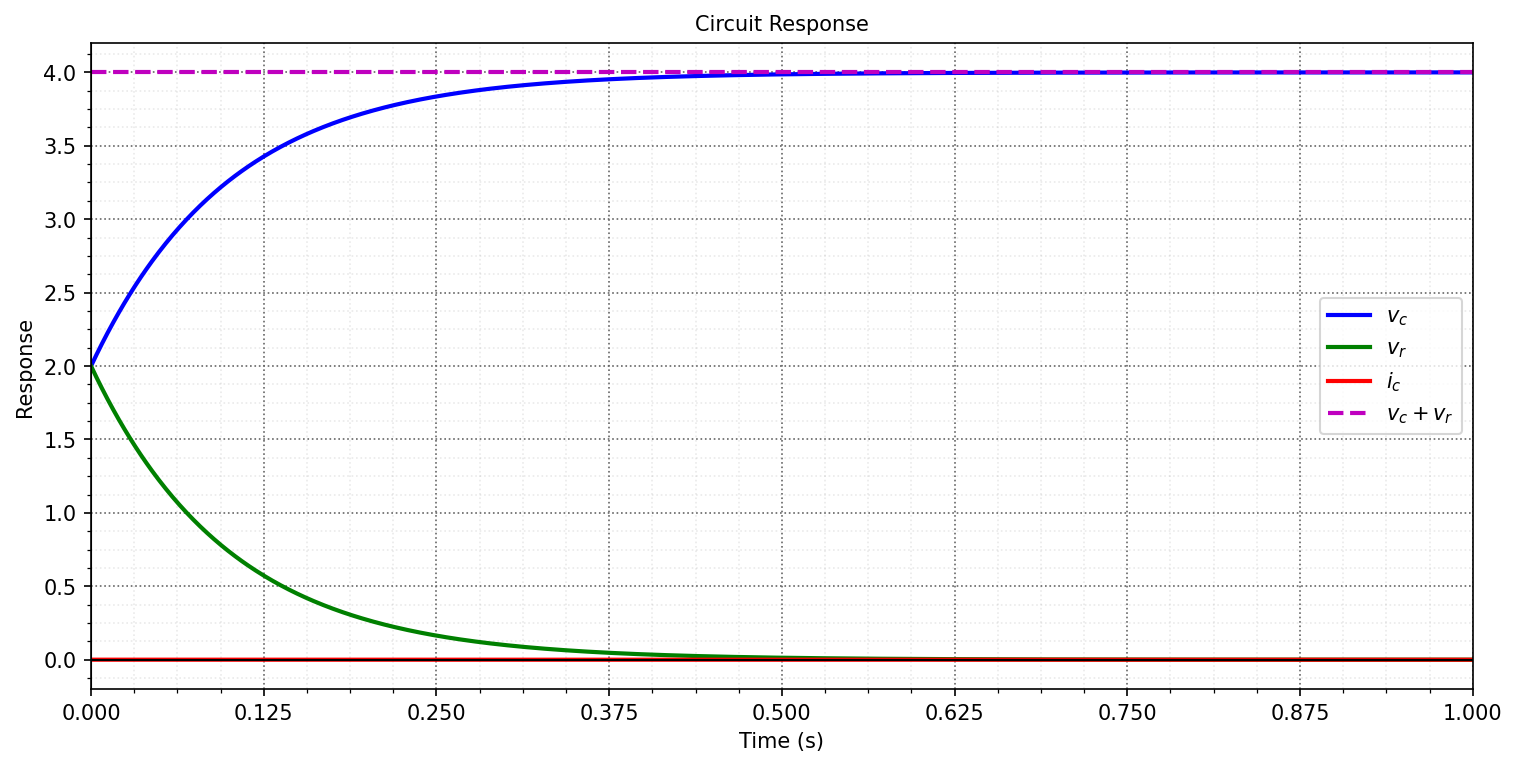

In [12]:
fig = figure(figsize=(10, 5),dpi=150,constrained_layout = True)
ax = fig.add_subplot(111, title='Circuit Response')
ax.plot(t, vc1, linewidth=2, color='blue', label='$v_c$')
ax.plot(t, vr1, linewidth=2, color='green', label='$v_r$')
ax.plot(t, ic1, linewidth=2, color='red', label='$i_c$')
ax.plot(t, vc1+vr1, 'm--', label='$v_c+v_r$')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Response');
nicegrid(ax)
plt.legend()
savefig('figs/circuit-VRC1.png')
plt.show()

In [13]:
cct1.C1.v

       -10⋅t           
4 - 2⋅ℯ       for t ≥ 0

# Network Example 2

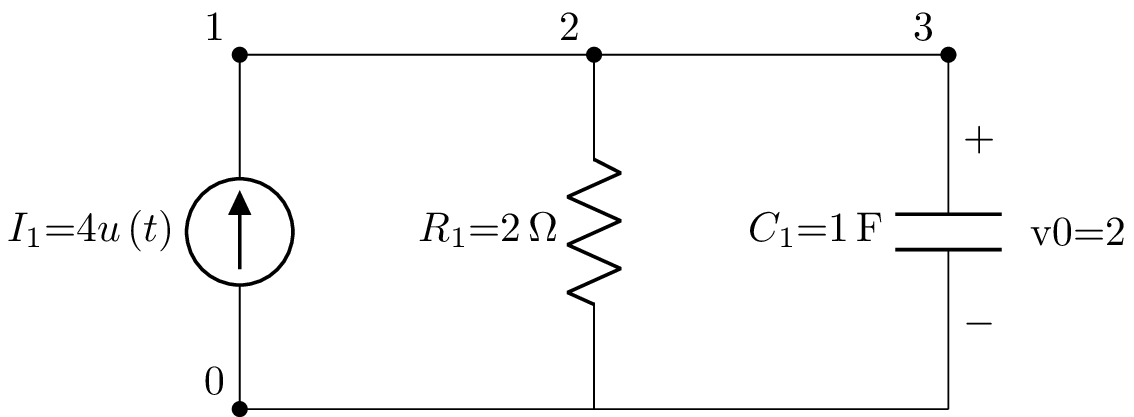

In [14]:
cct2 = Circuit("""
I1 1 0 {4*u(t)}; down=1.5
W1 1 2; right=1.5
R1 2 0_2 2; down=1.5
W2 2 3; right=1.5
C1 3 0_3 1 2; down=1.5
W3 0 0_2; right=1.5
W4 0_2 0_3; right=1.5
""")
cct2.draw()

In [15]:
t = np.linspace(0, 10, 1000)
vc2 = cct2.C1.v.evaluate(t)
ic2 = cct2.C1.i.evaluate(t)
ir2 = cct2.R1.i.evaluate(t)

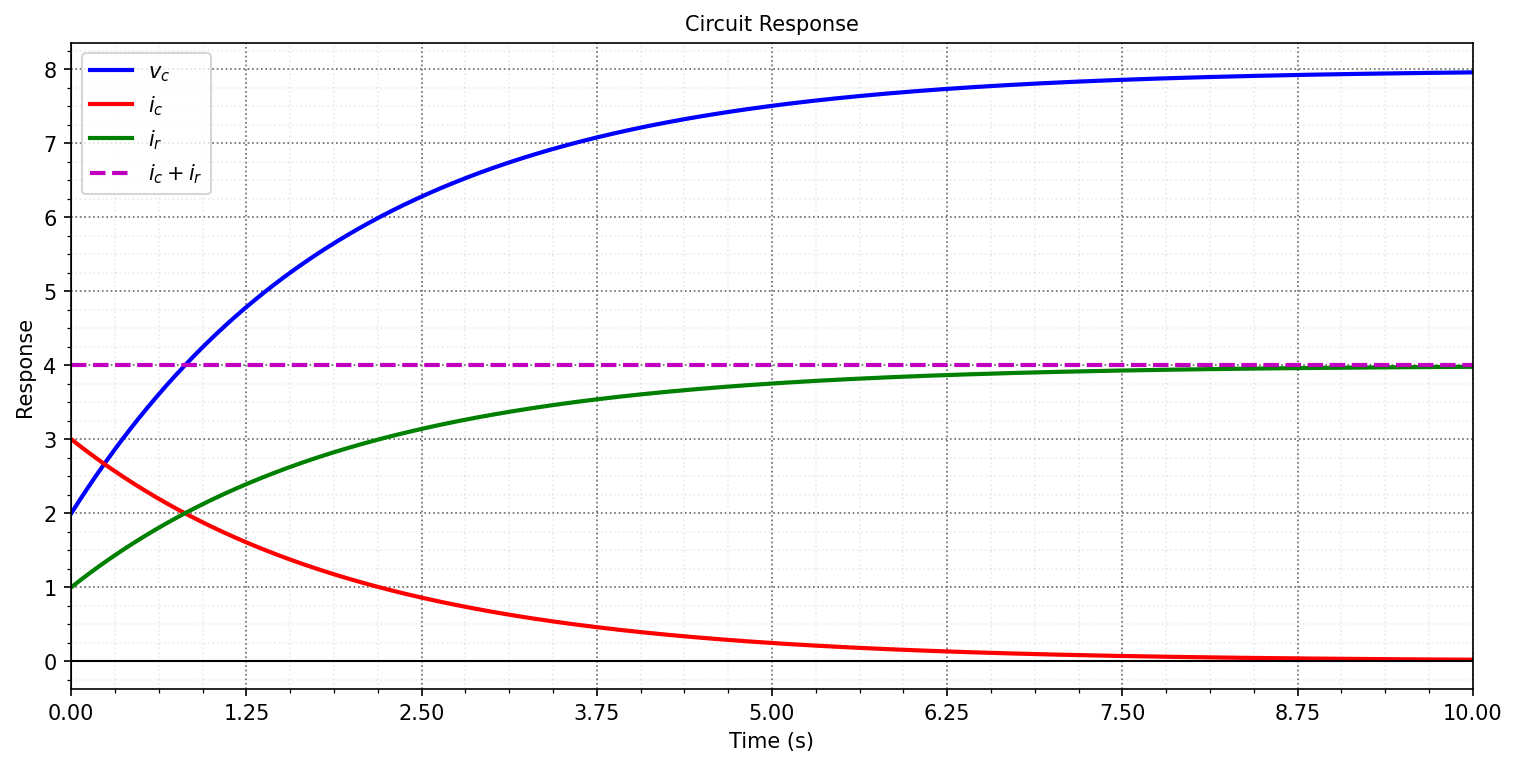

In [16]:
fig = figure(figsize=(10, 5),dpi=150,constrained_layout = True)
ax = fig.add_subplot(111, title='Circuit Response')
ax.plot(t, vc2, linewidth=2, color='blue', label='$v_c$')
ax.plot(t, ic2, linewidth=2, color='red', label='$i_c$')
ax.plot(t, ir2, linewidth=2, color='green', label='$i_r$')
ax.plot(t, ic2+ir2, 'm--', label='$i_c+i_r$')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Response');
nicegrid(ax)
plt.legend()
savefig('figs/circuit-VRC2.png')
plt.show()

In [17]:
cct2.C1.v

       -t            
       ───           
        2            
8 - 6⋅ℯ     for t ≥ 0

# Network Example 3

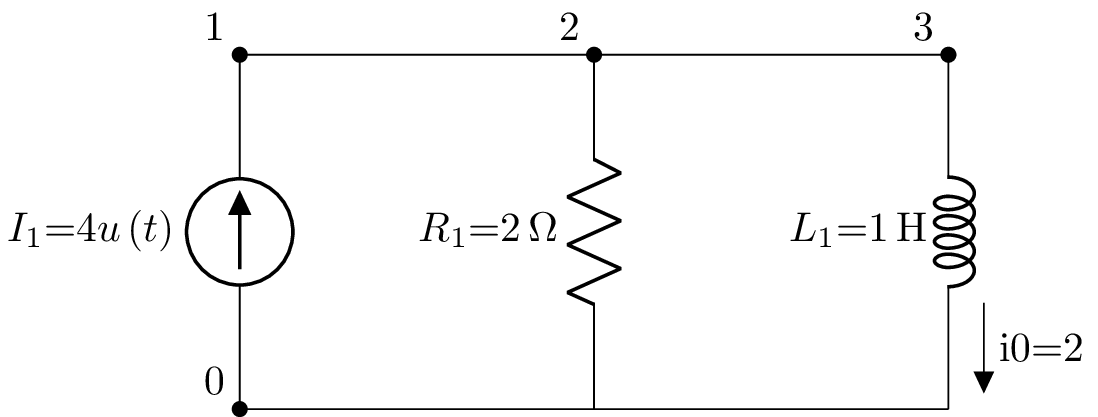

In [18]:
from lcapy import Circuit, s
cct3 = Circuit("""
I1 1 0 {4*u(t)}; down=1.5
W1 1 2; right=1.5
R1 2 0_2 2; down=1.5
W2 2 3; right=1.5
L1 3 0_3 1 2; down=1.5
W3 0 0_2; right=1.5
W4 0_2 0_3; right=1.5
""")
cct3.draw()

In [19]:
t = np.linspace(0, 4, 1000)
vl3 = cct3.L1.v.evaluate(t)
il3 = cct3.L1.i.evaluate(t)
ir3 = cct3.R1.i.evaluate(t)

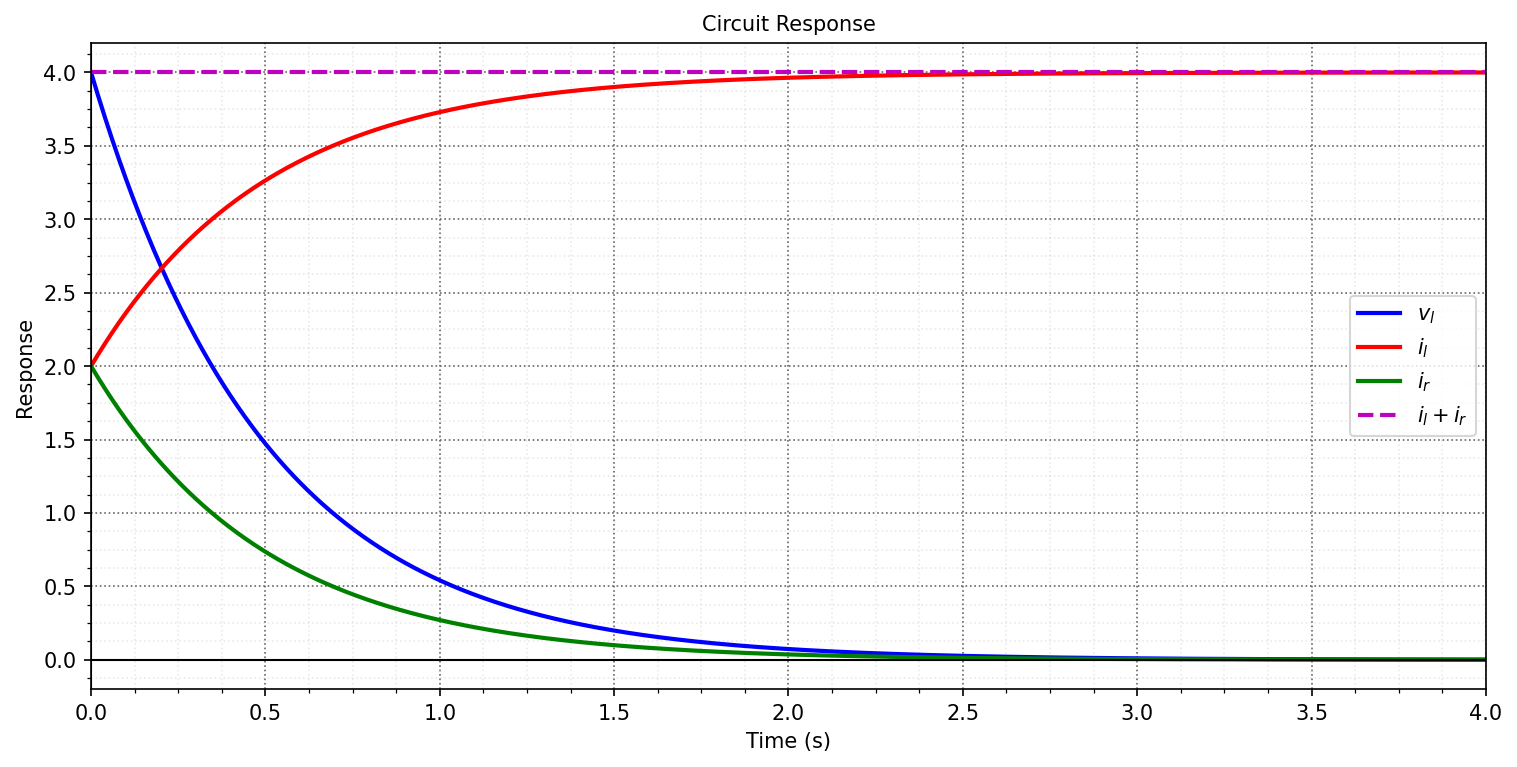

In [20]:
fig = figure(figsize=(10, 5),dpi=150,constrained_layout = True)
ax = fig.add_subplot(111, title='Circuit Response')
ax.plot(t, vl3, linewidth=2, color='blue', label='$v_l$')
ax.plot(t, il3, linewidth=2, color='red', label='$i_l$')
ax.plot(t, ir3, linewidth=2, color='green', label='$i_r$')
ax.plot(t, il3+ir3, 'm--', label='$i_l+i_r$')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Response');
nicegrid(ax)
plt.legend()
savefig('figs/circuit-VRC3.png')
plt.show()

In [21]:
cct3.L1.i

       -2⋅t           
4 - 2⋅ℯ      for t ≥ 0

# Analog Circuits to build Lead and Lag Functionality 

In [22]:
CC = 0.1e-6 # capacitor value
RR = 100e3 # res value
Rs1 = RR
Rs2 = 0.1*RR
zero = 1/Rs1/CC
print(f"{zero/2/np.pi = :8.3f} Hz")
RT = Rs1*Rs2/(Rs1+Rs2)
pole = 1/RT/CC
print(f"{pole/2/np.pi = :8.3f} Hz")

zero/2/np.pi =   15.915 Hz
pole/2/np.pi =  175.070 Hz


# Lead 

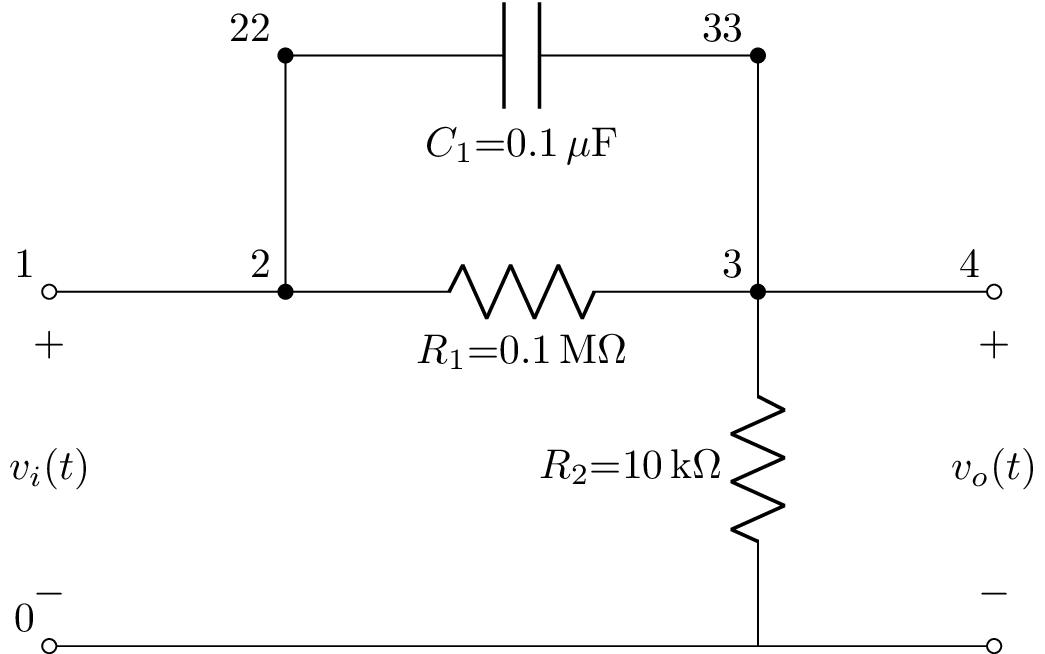

In [23]:
cct_lead = Circuit("""
P1 1 0 ; down=1.5, v_=v_i(t)
W1 1 2; right=1
R1 2 3 R; right=2
W22 2 22; up=1
C1 22 33 C; right=2
W33 33 3; down=1
R2 3 0_3 0.1*R; down=1.5
W03 0 0_3; right=1.5
W3 3 4; right=1
W04 0_3 0_4; right=1
P2 4 0_4; down, v^=v_o(t)
""")
cct8 = cct_lead.subs({'R': RR, 'C':CC})
cct8.draw()

In [24]:
cct_lead.P1.transfer('P2')

     1 
s + ───
    C⋅R
───────
     11
s + ───
    C⋅R

In [25]:
fv = logspace(0, 4, 1000)
w = fv *2*np.pi

Hl = cct8.P1.transfer('P2').limit('A', oo)
Num,Den = N(Hl).as_N_D()
NN = [Num.coeffs()[x].fval for x in range(len(Num.coeffs()))]
DD = [Den.coeffs()[x].fval for x in range(len(Den.coeffs()))]

G = tf(np.real(NN),np.real(DD))
print("Poles = "+', '.join('{:6.2f}'.format(x) for x in G.poles()/2/np.pi))
print("Zeros = "+', '.join('{:6.2f}'.format(x) for x in G.zeros()/2/np.pi))


Poles = -175.07+0.00j
Zeros = -15.92+0.00j


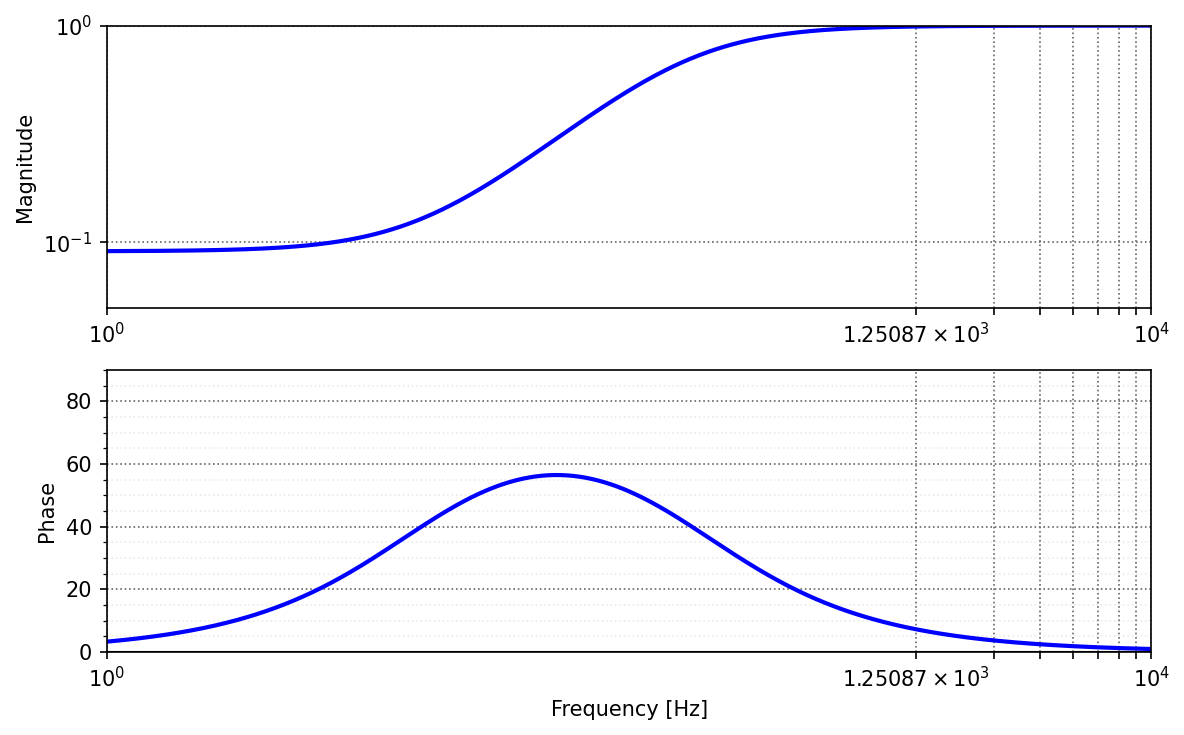

In [26]:
Gf = G(complex(0,1)*w)

fig, ax = plt.subplots(2,1,figsize=(8, 5),dpi=150)
ax[0].loglog(fv,np.abs(Gf),color='b',ls='-')
ax[1].semilogx(fv,np.angle(Gf)*r2d,color='b',ls='-')
ax[0].set_ylim([.05,1])
ax[1].set_ylim([0,90])
#ax[0].set_xlim([.1,10])
ax[0].set_ylabel("Magnitude")
ax[1].set_ylabel("Phase")
ax[1].set_xlabel("Frequency [Hz]")
nicegrid(ax)
savefig('figs/Analog_Lead.pdf',dpi=600)

#Digilent WaveForms Network Analyzer - Bode 
#Device Name: ADP3450 
#Serial Number: SN:210018B9D810 
#Date Time: 2024-01-16 20:42:32.482 
#Start: 1 Hz 
#Stop: 10000 Hz 
#Steps: 201 
#Wavegen: Wavegen C1 
#Amplification: 1 X 
#Settle: 10 ms 
#MinPeriods: 16  
#Channel: Channel 1 
#Range: 2.1613 V 
#Offset: 3.34838e-06 V 
#Relative: yes 
#Wavegen Channel 2: Disabled 
#Mode: Simple 
#Type: Sine 
#Frequency: 1 kHz 
#Period: 1 ms 
#Amplitude: 1 V 
#Offset: 0 V 
#Symmetry: 50 % 
#Phase: 0 ° 
# Frequency (Hz) Channel 1 Magnitude (X), Channel 1 Phase (deg)


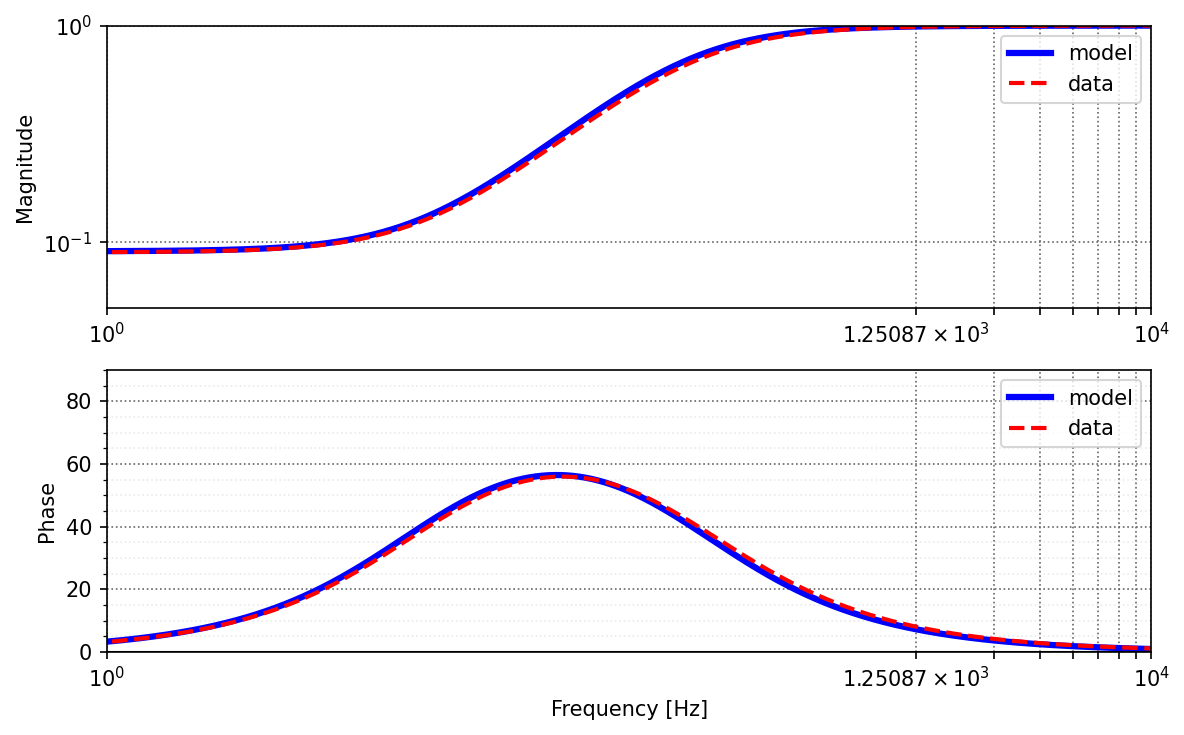

In [27]:
#Data
data = Read_csv_data("/Users/jonathanhow/Dropbox (MIT)/Classes/16.06/Spr_2024/Source/Circuit/Analog_Lag_lead.csv")

fig, ax = plt.subplots(2,1,figsize=(8, 5),dpi=150)
ax[0].loglog(fv,np.abs(Gf),color='b',ls='-',lw=3,label='model')
ax[0].loglog(data[:,0],data[:,1],color='r',ls='--',label='data')
ax[1].semilogx(fv,np.angle(Gf)*r2d,color='b',ls='-',lw=3,label='model')
ax[1].semilogx(data[:,0],data[:,2],color='r',ls='--',label='data')
ax[0].set_ylim([.05,1])
ax[1].set_ylim([0,90])
ax[0].set_ylabel("Magnitude")
ax[1].set_ylabel("Phase")
ax[1].set_xlabel("Frequency [Hz]")
ax[0].legend()
ax[1].legend()
nicegrid(ax)
savefig('figs/Analog_Lead_with_data.pdf',dpi=600)

# Lag Lead

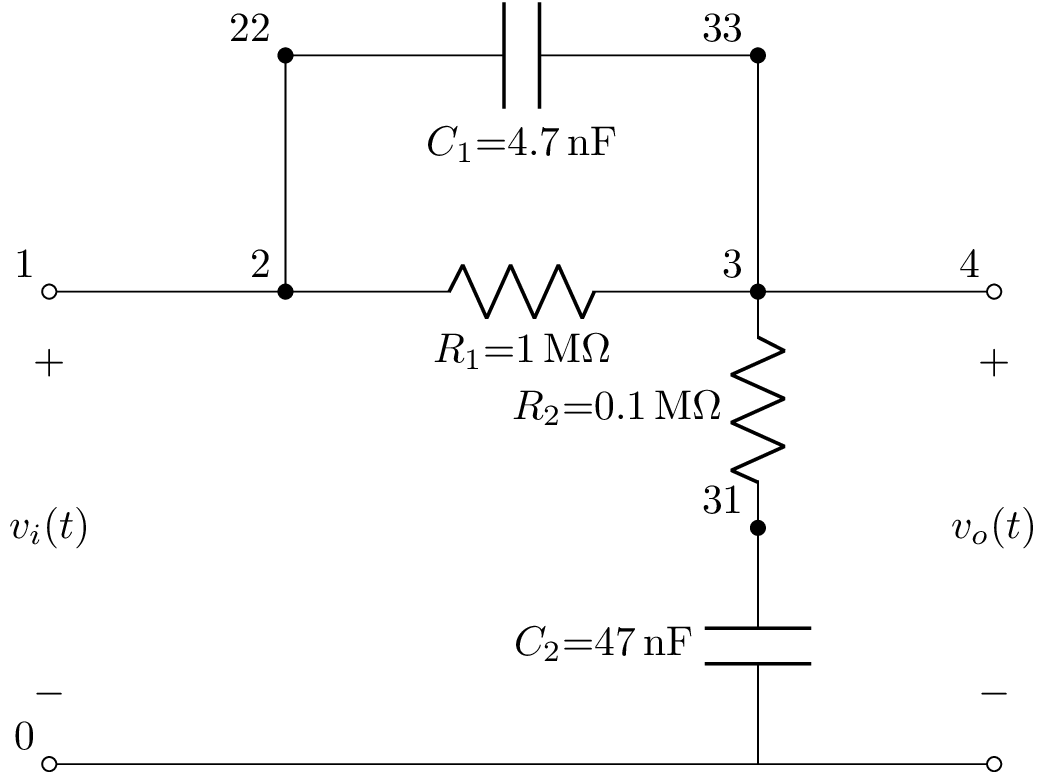

In [28]:
cct_lead = Circuit("""
P1 1 0 ; down=1.5, v_=v_i(t)
W1 1 2; right=1
R1 2 3 10*R; right=2
W22 2 22; up=1
C1 22 33 .047*C; right=2
W33 33 3; down=1
R2 3 31 R; down=1
C2 31 0_3 .47*C; down=1
W03 0 0_3; right=1.5
W3 3 4; right=1
W04 0_3 0_4; right=1
P2 4 0_4; down, v^=v_o(t)
""")
cct8 = cct_lead.subs({'R': RR, 'C':CC, 'C2':CC})
cct8.draw()

In [29]:
cct_lead.P1.transfer('P2')

 2   200⋅s      10000   
s  + ────── + ──────────
     47⋅C⋅R         2  2
              2209⋅C ⋅R 
────────────────────────
 2   1200⋅s     10000   
s  + ────── + ──────────
     47⋅C⋅R         2  2
              2209⋅C ⋅R 

In [30]:
Hl = cct8.P1.transfer('P2').limit('A', oo)
Num,Den = N(Hl).as_N_D()
NN = [Num.coeffs()[x].fval for x in range(len(Num.coeffs()))]
DD = [Den.coeffs()[x].fval for x in range(len(Den.coeffs()))]

G = tf(np.real(NN),np.real(DD))
print("Poles = "+', '.join('{:6.2f}'.format(x) for x in G.poles()/2/np.pi))
print("Zeros = "+', '.join('{:6.2f}'.format(x) for x in G.zeros()/2/np.pi))
G

Poles = -403.51+0.00j, -2.84+0.00j
Zeros = -33.86+0.00j, -33.86+0.00j


TransferFunction(array([   1.000,  425.532,  45269.353]), array([   1.000,  2553.191,  45269.353]))

#Digilent WaveForms Network Analyzer - Bode 
#Device Name: ADP3450 
#Serial Number: SN:210018B9D810 
#Date Time: 2024-01-16 21:33:58.138 
#Start: 1 Hz 
#Stop: 1000 Hz 
#Steps: 201 
#Wavegen: Wavegen C1 
#Amplification: 1 X 
#Settle: 10 ms 
#MinPeriods: 16  
#Channel: Channel 1 
#Range: 2.1613 V 
#Offset: 3.34838e-06 V 
#Relative: yes 
#Wavegen Channel 2: Disabled 
#Mode: Simple 
#Type: Sine 
#Frequency: 1 kHz 
#Period: 1 ms 
#Amplitude: 1 V 
#Offset: 0 V 
#Symmetry: 50 % 
#Phase: 0 ° 
#Frequency (Hz) Channel 1 Magnitude (X), Channel 1 Phase (deg)


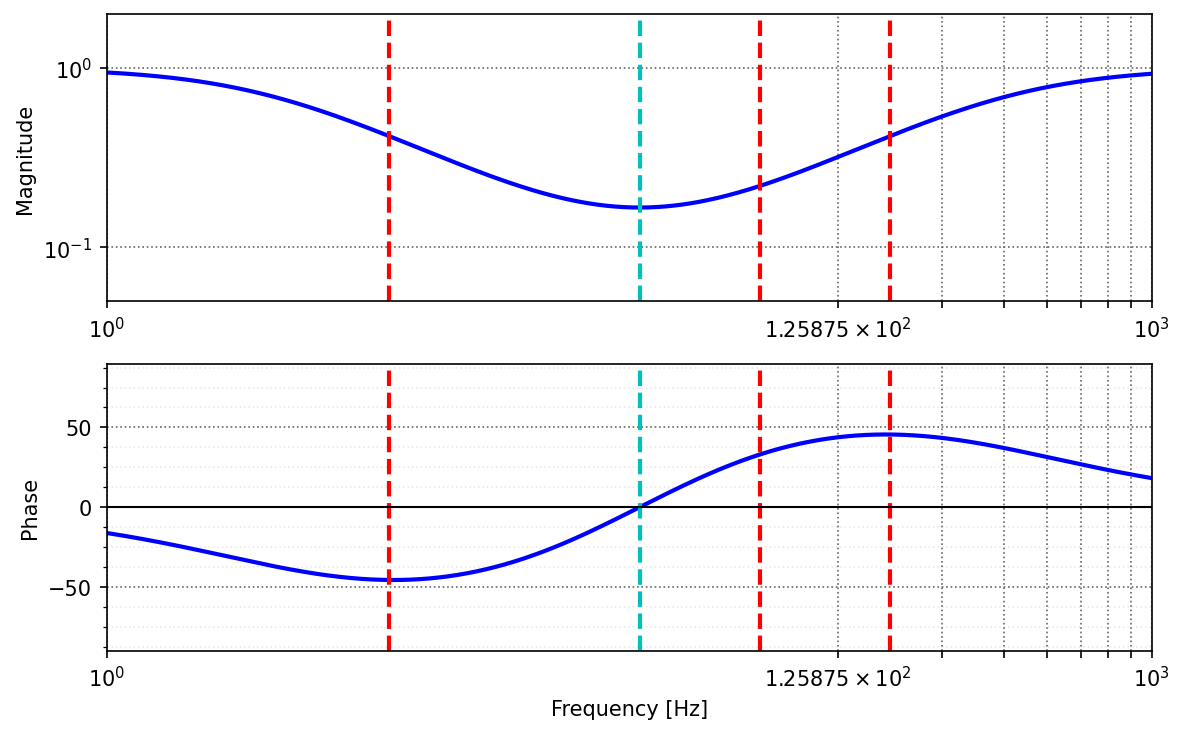

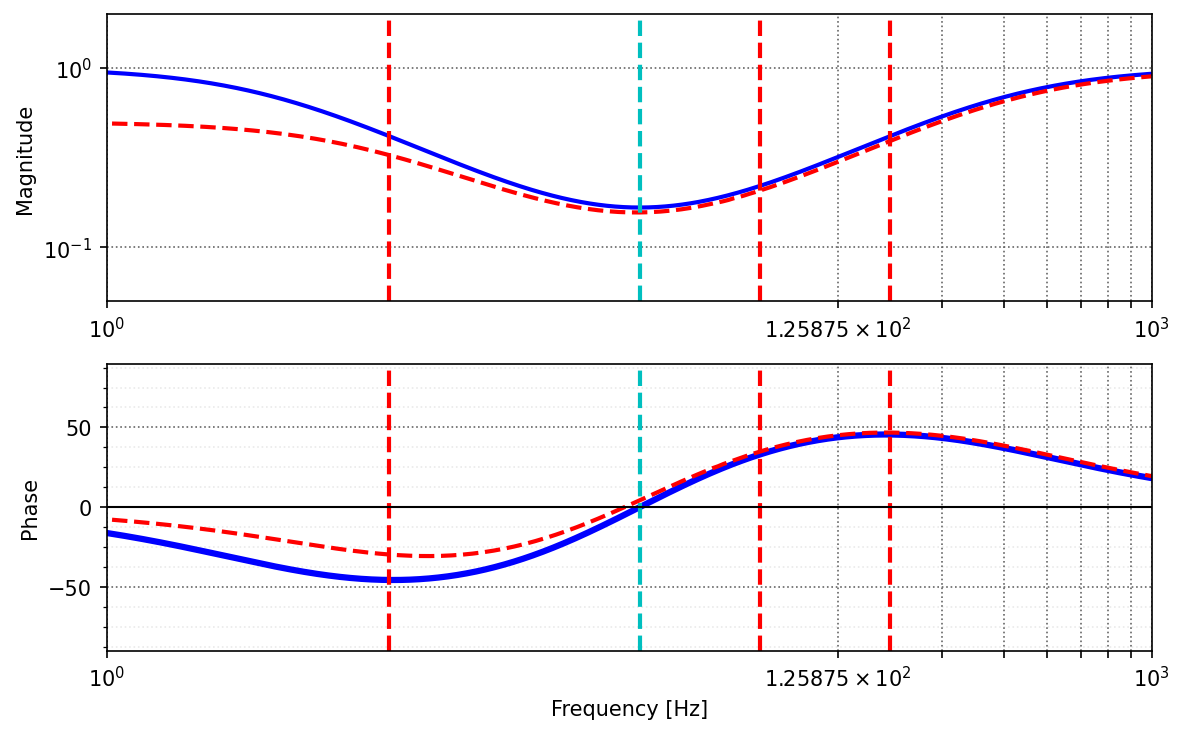

In [31]:
fv = logspace(0, 3, 1000)
Gf = G(complex(0,1)*fv*2*np.pi)

fig, ax = plt.subplots(2,1,figsize=(8, 5),dpi=150)
ax[0].loglog(fv,np.abs(Gf),color='b',ls='-')
ax[1].semilogx(fv,np.angle(Gf)*r2d,color='b',ls='-')
ax[0].set_ylim([.05,2])
ax[1].set_ylim([-90,90])
ax[0].set_ylabel("Magnitude")
ax[1].set_ylabel("Phase")
ax[1].set_xlabel("Frequency [Hz]")
for ii in range(2):
    [ax[ii].axvline(x=np.abs(p/2/np.pi),c='r',ls='--') for p in lpoles]
    [ax[ii].axvline(x=np.abs(z/2/np.pi),c='c',ls='--') for z in lzeros]
nicegrid(ax)
savefig('figs/Analog_Lag_Lead.pdf',dpi=600)

data = Read_csv_data("/Users/jonathanhow/Dropbox (MIT)/Classes/16.06/Spr_2024/Source/Circuit/Analog_Lag_lead2.csv")

fig, ax = plt.subplots(2,1,figsize=(8, 5),dpi=150)
ax[0].loglog(fv,np.abs(Gf),color='b',ls='-',label='model')
ax[0].loglog(data[:,0],data[:,1],color='r',ls='--',label='data')
ax[1].semilogx(fv,np.angle(Gf)*r2d,color='b',ls='-',lw=3,label='model')
ax[1].semilogx(data[:,0],data[:,2],color='r',ls='--',label='data')
ax[0].set_ylim([.05,2])
ax[1].set_ylim([-90,90])
ax[0].set_ylabel("Magnitude")
ax[1].set_ylabel("Phase")
ax[1].set_xlabel("Frequency [Hz]")
for ii in range(2):
    [ax[ii].axvline(x=np.abs(p/2/np.pi),c='r',ls='--') for p in lpoles]
    [ax[ii].axvline(x=np.abs(z/2/np.pi),c='c',ls='--') for z in lzeros]
nicegrid(ax)
savefig('figs/Analog_Lag_Lead_with_data.pdf',dpi=600)


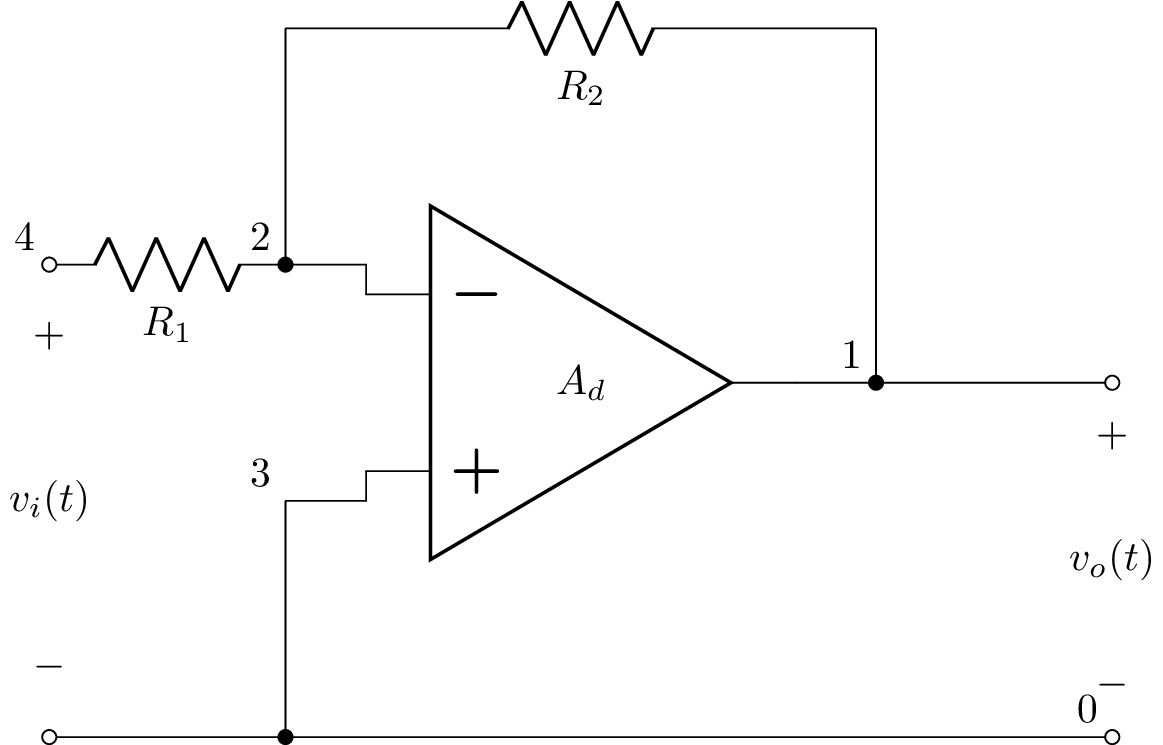

-R₂ 
────
 R₁ 

In [32]:
from lcapy import Circuit, t, oo
a = Circuit("""
E 1 0 opamp 3 2 Ad; right, flipud, scale = 0.75
R1 4 2; right
R2 2_2 1_1; right
W 2 2_2; up
W 1 1_1; up
Pi 4 0_1; down, v^=v_i(t)
W 3 0_2; down
W 1 1_2; right
Po 1_2 0; down, v^=v_o(t)
W 0_1 0_2; right
W 0_2 0; right
; draw_nodes=connections, label_ids=none, label_nodes=primary
""")
a.draw()
a.Pi.transfer('Po').limit('Ad', oo)

## Active Lead

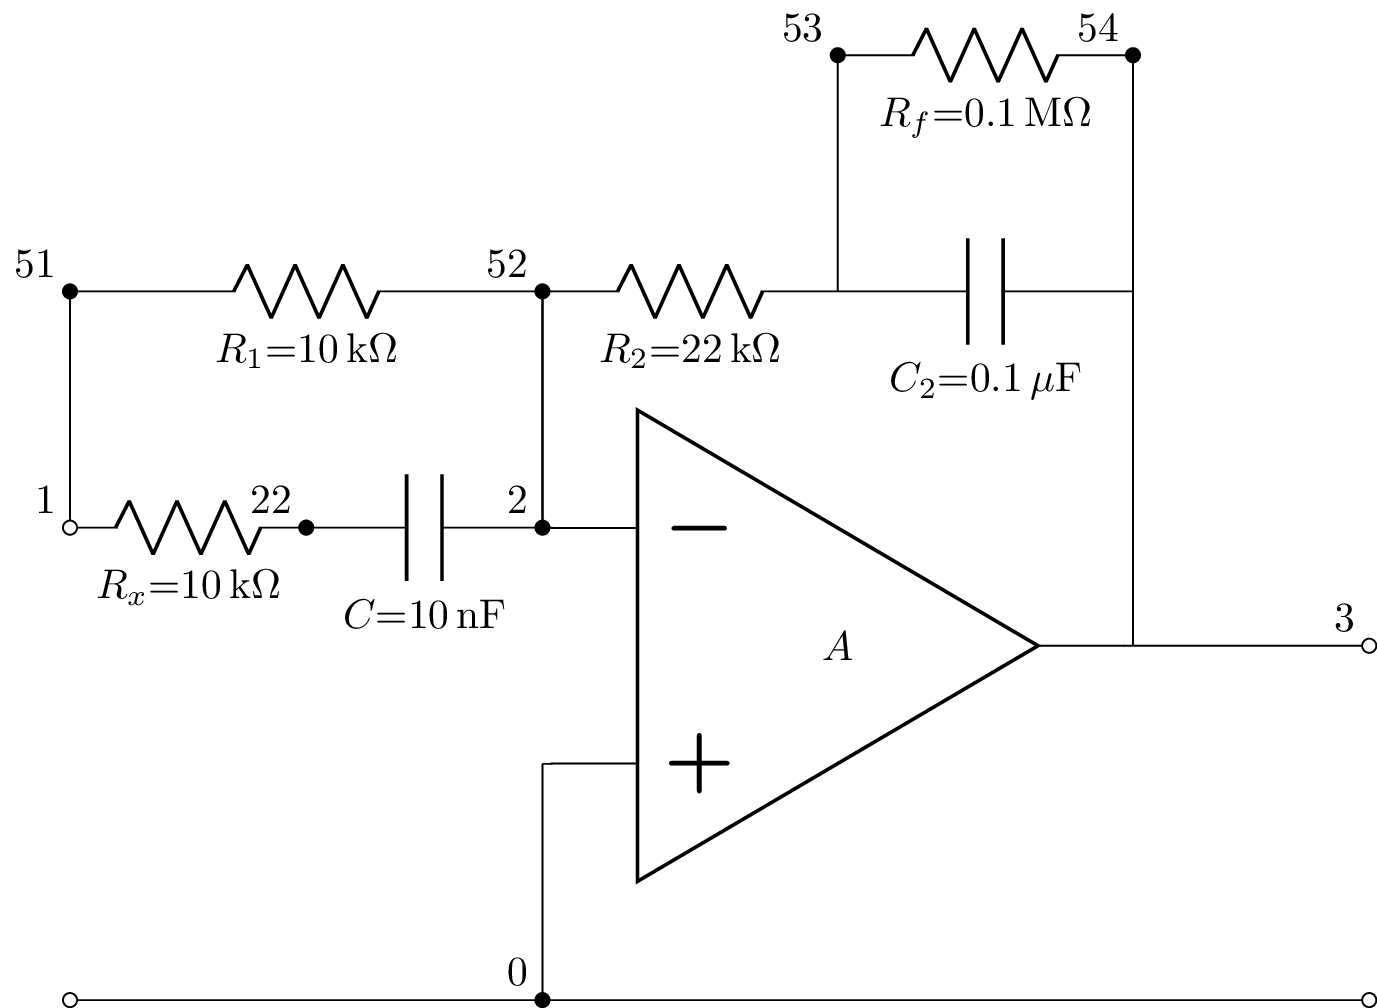

In [33]:
CC = 0.1e-6 # capacitor value
RR = 10e3 # res value

cct_test1 = Circuit("""
P1 1 0_1; down
Rx 1 22; right
C 22 2; right
W 1 51; up 
W 2 52; up 
R1 51 52; right
R2 2_1 4_1; right
C2 4_1 3_1; right
W 4_1 53; up 
W 3_1 54; up 
Rf 53 54; right
E1 3_2 0_3 opamp 2_0 2 A; mirror
W 0_1 0; right
W 2_0 0; down
W 3_2 3; right
W 0 0_3; right
P2 3 0_3; down
W 2_1 2; down
W 3_1 3_2; down
""")
cct9 = cct_test1.subs({'Rx': RR, 'R1': RR, 'R2': 2.2*RR, 'Rf': 10*RR, 'C':CC/10, 'C1':CC, 'C2':CC})
cct9.draw()


In [34]:
Hl = cct9.P1.transfer('P2').limit('A', oo)
Num,Den = N(Hl).as_N_D()
NN = [Num.coeffs()[x].fval for x in range(len(Num.coeffs()))]
DD = [Den.coeffs()[x].fval for x in range(len(Den.coeffs()))]

G = tf(np.real(NN),np.real(DD))
print("Poles = "+', '.join('{:6.2f}'.format(x) for x in G.poles()/2/np.pi))
print("Zeros = "+', '.join('{:6.2f}'.format(x) for x in G.zeros()/2/np.pi))
G

Poles = -1591.55+0.00j, -15.92+0.00j
Zeros = -795.77+0.00j, -88.26+0.00j


TransferFunction(array([  -4.400, -24440.000, -12200000.000]), array([   1.000,  10100.000,  1000000.000]))

## weird circuit

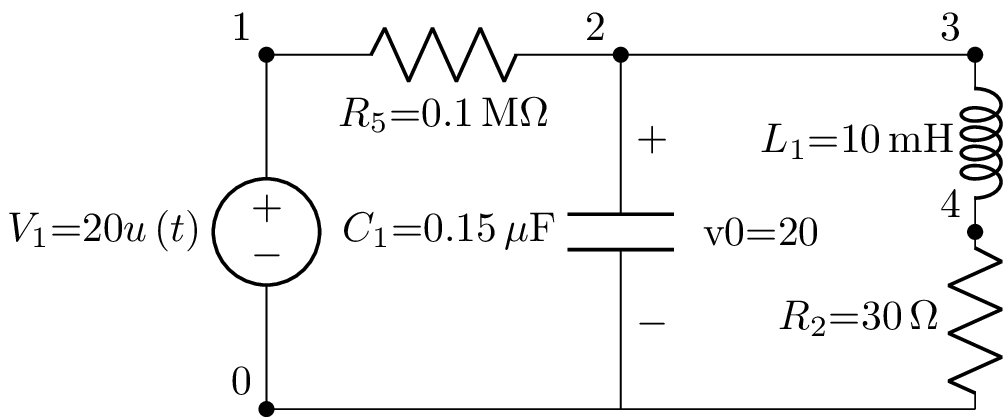

In [35]:
cct5 = Circuit("""
V1 1 0 {20*u(t)}; down=1.5
R5 1 2 1e5; right=1.5
C1 2 0_2 1.5e-7 20; down=1.5
W2 2 3; right=1.5
L1 3 4 0.01; down=0.75
R2 4 0_3 30; down=0.75
W3 0 0_2; right=1.5
W4 0_2 0_3; right=1.5
""")
cct5.draw()

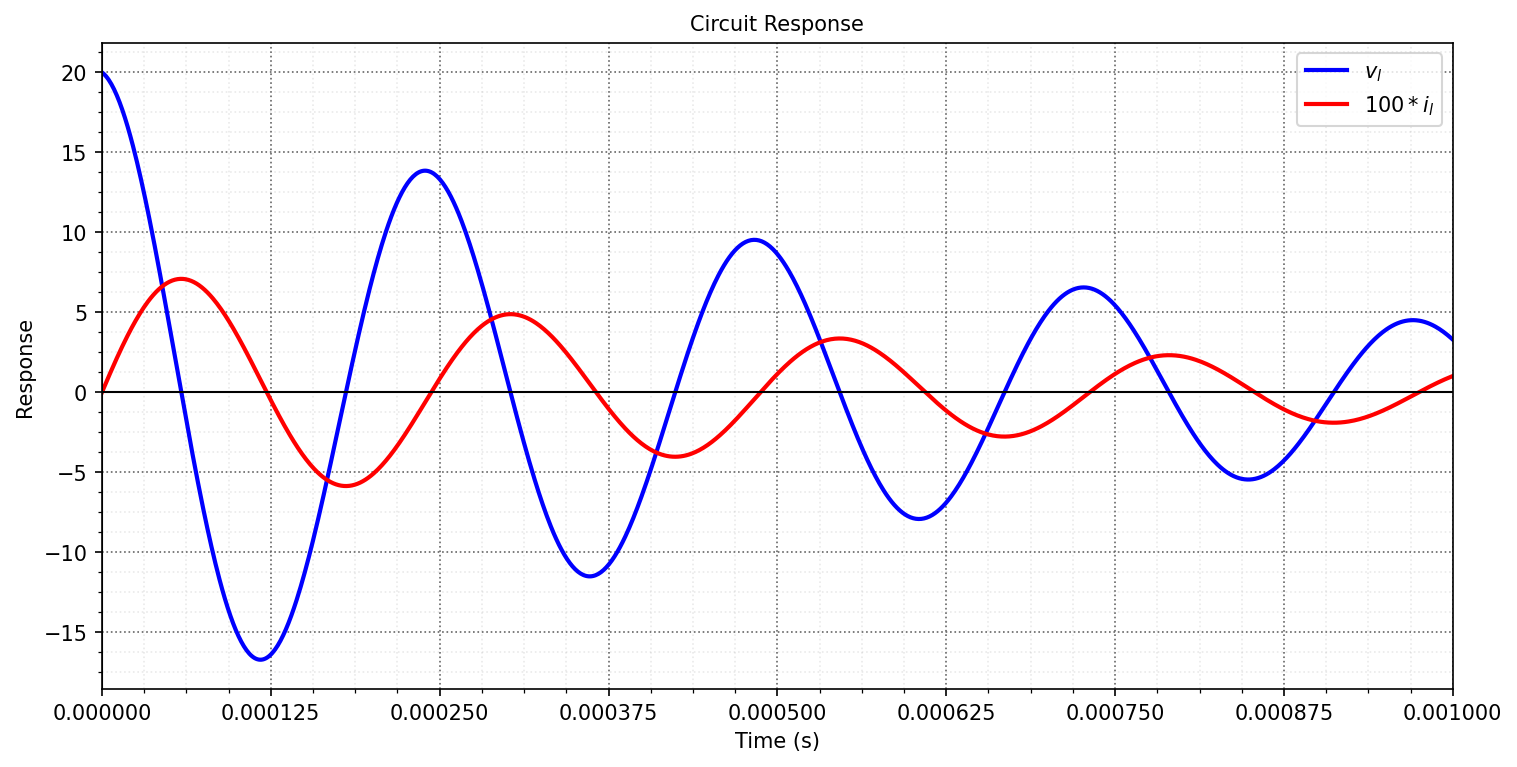

In [36]:
t5 = np.linspace(0,.001, 1000)
#t5 = np.linspace(0,.1, 1000)
vl5 = cct5.L1.v.evaluate(t5)
il5 = cct5.L1.i.evaluate(t5)
vr5 = cct5.R2.v.evaluate(t5)
vc5 = cct5.C1.v.evaluate(t5)

fig = figure(figsize=(10, 5),dpi=150,constrained_layout = True)
ax = fig.add_subplot(111, title='Circuit Response')
ax.plot(t5, vl5, linewidth=2, color='blue', label='$v_l$')
ax.plot(t5, 100*il5, linewidth=2, color='red', label='$100*i_l$')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Response');
#ax.set_ylim([-.1,.1])
nicegrid(ax)
plt.legend()
#savefig('figs/circuit-VRC1.png')
plt.show()

In [37]:
print(cct5.R2.i.evaluate(1).item())
cct5.C1.v.evaluate(1).item()

0.0001999400179946016


# Discrete Time

[5e-05]
[596.075295947766, 5960.75295947766]
A= 0.8832769848601092
B= -0.8573385370512445
C= -0.7406155219113537


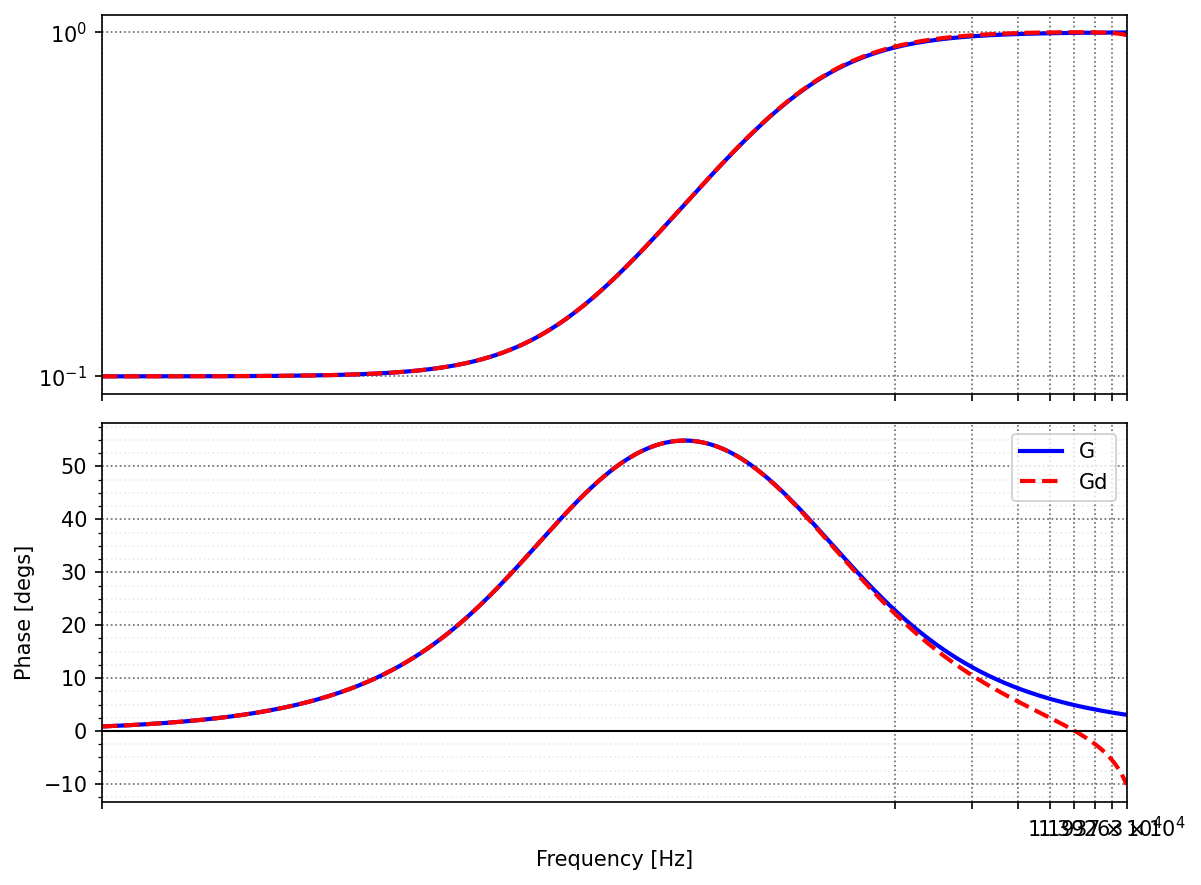

In [42]:
def pshift(Gp):
    if np.max(Gp*r2d) < -180.0:
        return Gp + 2*np.pi
    if np.max(Gp*r2d) > 180.0:
        return Gp - 2*np.pi
    else:
        return Gp

    
import control as ct
from control.matlab import rss, lsim, c2d

Ts = 50e-6
print([Ts])
wc = 300*2*np.pi
z = np.sqrt(wc**2/10)
p = 10*z
print([z,p])
sysc = ct.TransferFunction([1, z], [1, p])
sysd = ct.matlab.c2d(sysc, Ts, method='bilinear')

print("A=",float(sysd.num[0][0][0]))
print("B=",float(sysd.num[0][0][1]))
print("C=",float(sysd.den[0][0][1]))

w = np.sort(np.append(logspace(1,5,2000),wc))
[Gm,Gp,Gw]=ct.bode_plot(sysc,plot=False,omega=w)
[Gmd,Gpd,Gwd]=ct.bode_plot(sysd,plot=False,omega=w)
fig, ax = plt.subplots(2,1,figsize=(8, 6),dpi=150,sharex = True)
ax[0].loglog(Gw/2/np.pi,Gm,'b-',label='G')
ax[0].loglog(Gwd/2/np.pi,Gmd,'r--',label='Gd')
ax[1].semilogx(Gw/2/np.pi,pshift(Gp)*r2d,'b-',label='G')
ax[1].semilogx(Gwd/2/np.pi,pshift(Gpd)*r2d,'r--',label='Gd')
ax[1].legend()
ax[1].set_xlim([min(w/2/np.pi),max(w/2/np.pi)])
ax[1].set_xlabel("Frequency [Hz]")
ax[1].set_ylabel("Phase [degs]")
nicegrid(ax)
plt.legend()
plt.show()

[2e-05]
[596.075295947766, 5960.75295947766]
10.186695669379628
A= 9.670954348217096
B= -9.556345165736534
C= -0.8874913061110992


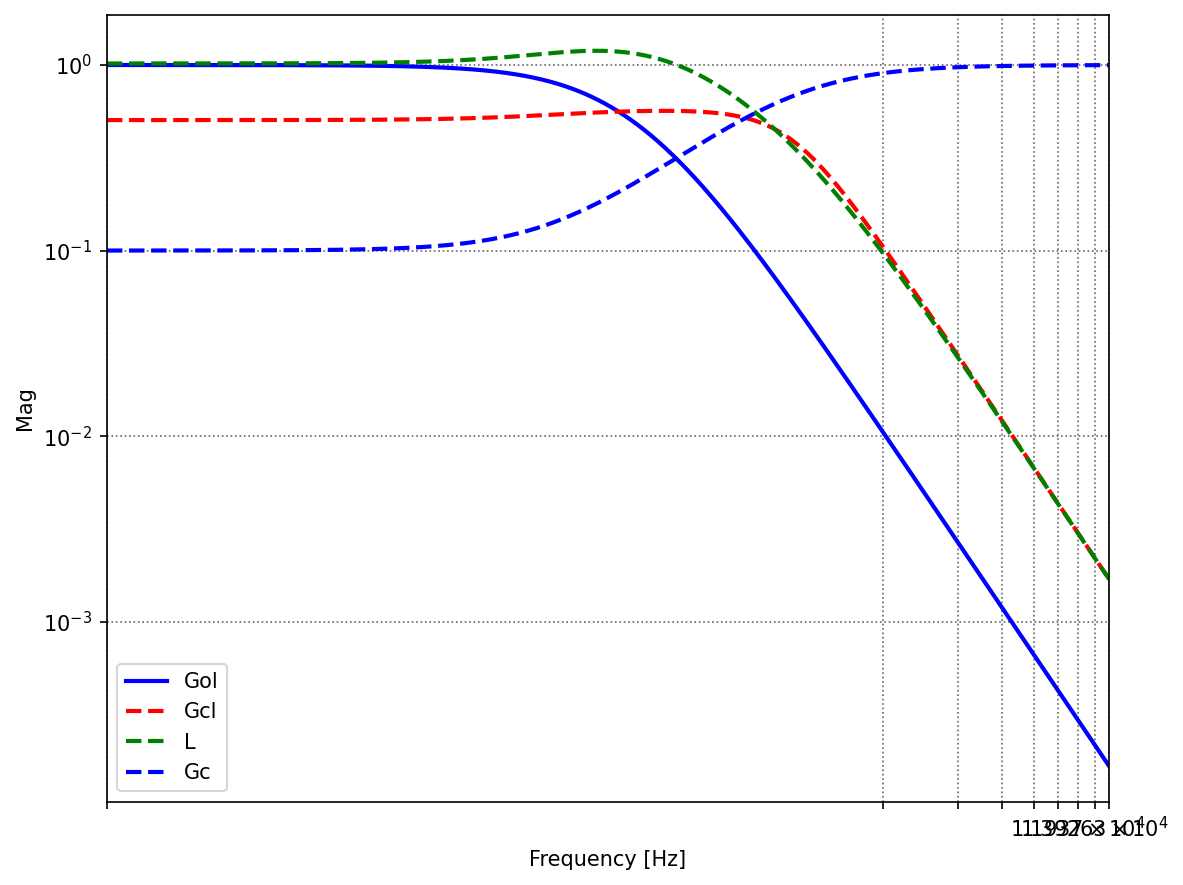

In [43]:
CC = 2*10e-6 # capacitor value
LL = 30e-3 # inductor value
RR = 80 # res value
a=1;b=RR/LL;c=1/LL/CC
Gol = ct.TransferFunction([c], [a,b,c])

Ts = 20e-6
print([Ts])

gamma = 10
wc = 300*2*np.pi
z = np.sqrt(wc**2/gamma)
p = gamma*z
print([z,p])
sysc = ct.TransferFunction([1, z], [1, p])

w = np.sort(np.append(logspace(1,5,2000),wc))
[Gm,Gp,Gw]=ct.bode_plot(sysc,plot=False,omega=w)
[Gmd,Gpd,Gwd]=ct.bode_plot(sysd,plot=False,omega=w)

L = Gol*sysc
k_c = float(np.abs(np.polyval(L.den[0][0],j*wc)/np.polyval(L.num[0][0],j*wc)))
print(k_c)
sysc = ct.TransferFunction([k_c, k_c*z], [1, p])
L = Gol*sysc

Gcl = L/(1+L)
[Golm,Golp,Golw]=ct.bode_plot(Gol,plot=False,omega=w)
[Lm,Lp,Lw]=ct.bode_plot(L,plot=False,omega=w)
[Gclm,Gclp,Gclw]=ct.bode_plot(Gcl,plot=False,omega=w)

sysd = ct.matlab.c2d(sysc, Ts, method='bilinear')
print("A=",float(sysd.num[0][0][0]))
print("B=",float(sysd.num[0][0][1]))
print("C=",float(sysd.den[0][0][1]))

fig, ax = plt.subplots(1,figsize=(8, 6),dpi=150,sharex = True)
ax.semilogx(Golw/2/np.pi,Golm,'b-',label='Gol')
ax.semilogx(Gclw/2/np.pi,Gclm,'r--',label='Gcl')
ax.semilogx(Lw/2/np.pi,Lm,'g--',label='L')
ax.loglog(Gw/2/np.pi,Gm,'b--',label='Gc')
ax.legend()
ax.set_xlim([min(w/2/np.pi),max(w/2/np.pi)])
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Mag")
nicegrid(ax)
plt.legend()
plt.show()

In [44]:
[float(k_c), k_c*z]

In [45]:
sysd

TransferFunction(array([   9.671,   -9.556]), array([   1.000,   -0.887]), 2e-05)

In [46]:
def fmap(x, in_min, in_max, out_min, out_max):
    return (x - in_min) * (out_max - out_min) / (in_max - in_min) + out_min

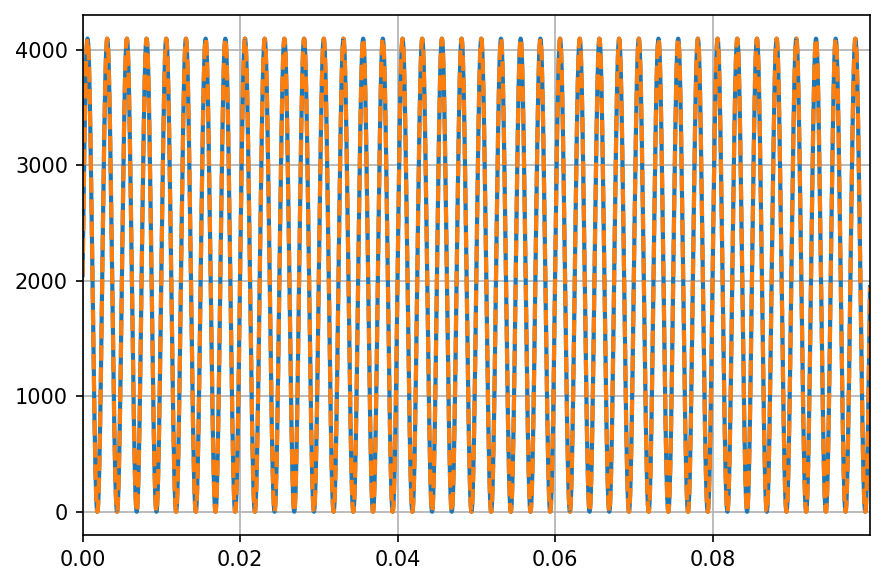

In [73]:
Nscale=2**12-1
t = np.arange(0,.1,Ts)
u500 = Nscale/2*np.sin(400*2*np.pi*t)+Nscale/2
us = fmap(u500,0,Nscale,-1,1)
ys = fmap(us,-1,1,0,Nscale)
fig, ax = plt.subplots(1,figsize=(6, 4),dpi=150,sharex = True)
plt.plot(t,ys,t,u500,'--')
plt.show()

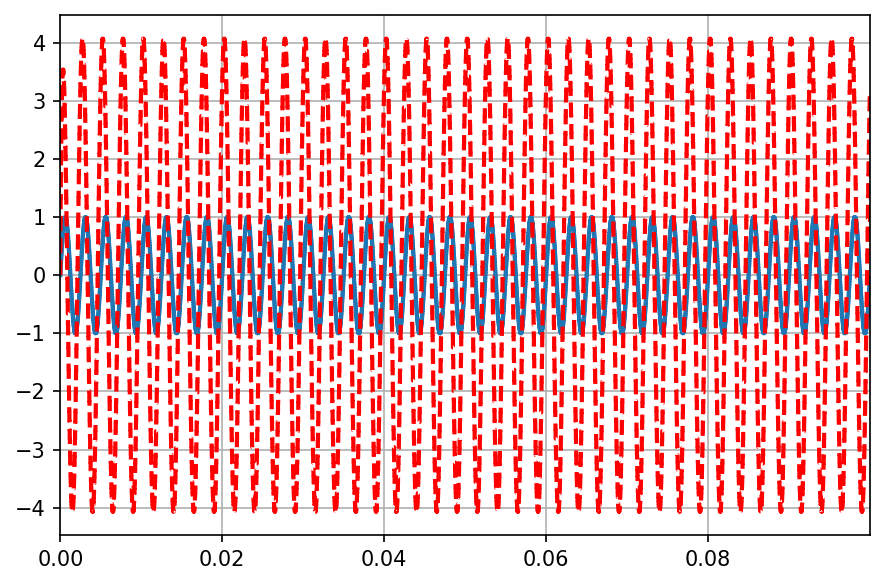

In [72]:
yout, T, xout = lsim(sysd,us,T=t)
fig, ax = plt.subplots(1,figsize=(6, 4),dpi=150,sharex = True)
plt.step(t,us,T,yout,'r--')
plt.show()

# Resonant Dynamics

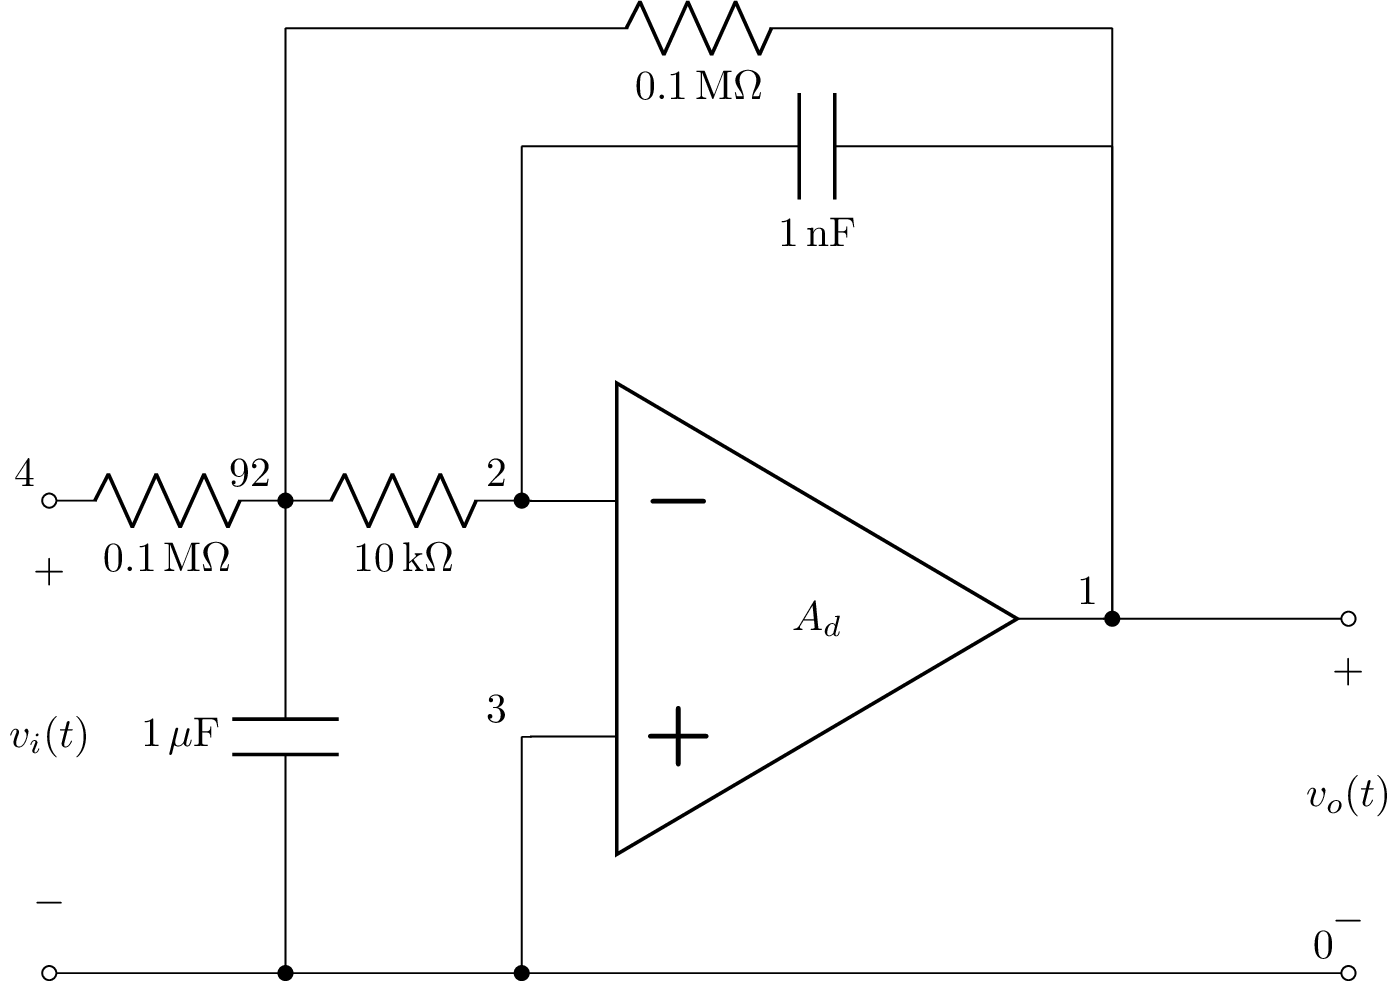

In [49]:
a = Circuit("""
E 1 0 opamp 3 2 Ad; right, flipud
R1 4 92; right
R2 92 2; right
W 92 2_2; up=2
R3 2_2 1_1; right
W 1_1 1; down
#
W 2 2_8; up=1.5
C2 2_8 3_8;right
W 3_8 1;down
#
Pi 4 0_1; down, v^=v_i(t)
W 3 0_2; down
W 1 1_2; right
Po 1_2 0; down, v^=v_o(t)
W 0_1 0_92; right
W 0_92 0_2; right
W 0_2 0; right
C1 92 0_92; down
; draw_nodes=connections, label_ids=none, label_nodes=primary
""")
cct10 = a.subs({'R1': 100e3, 'R2': 10e3, 'R3': 1e5, 'C1': 1*1e-6, 'C2': 1e-9})
cct10.draw()

In [50]:
from sympy import sqrt, simplify, N
RR = a.Pi.transfer('Po').limit('Ad', oo)
hh = RR.as_N_D()[1]
hhh = hh.coeffs()
wn = (hhh[2]/hhh[0])**(0.5)
print(wn)
zeta = ((hhh[1]/hhh[0])/2/wn).limit('R1', oo)
zeta

1/(sqrt(C1)*sqrt(C2)*sqrt(R2)*sqrt(R3))


        C₂⋅R₂ + C₂⋅R₃        
─────────────────────────────
    ____   ____   ____   ____
2⋅╲╱ C₁ ⋅╲╱ C₂ ⋅╲╱ R₂ ⋅╲╱ R₃ 

In [51]:
Hl = cct10.Pi.transfer('Po').limit('Ad', oo)
Num,Den = N(Hl).as_N_D()
NN = [Num.coeffs()[x].fval for x in range(len(Num.coeffs()))]
DD = [Den.coeffs()[x].fval for x in range(len(Den.coeffs()))]

G = tf(np.real(NN),np.real(DD))
print("Poles = "+', '.join('{:6.2f}'.format(x) for x in G.poles()))
print("Zeros = "+', '.join('{:6.2f}'.format(x) for x in G.zeros()))

G

Poles = -60.00+998.20j, -60.00-998.20j
Zeros = 


TransferFunction(array([-1000000.000]), array([   1.000,  120.000,  1000000.000]))

#Digilent WaveForms Network Analyzer - Bode 
#Device Name: ADP3450 
#Serial Number: SN:210018B9D810 
#Date Time: 2024-01-17 20:01:52.326 
#Start: 1 Hz 
#Stop: 10000 Hz 
#Steps: 201 
#Wavegen: Wavegen C1 
#Amplification: 1 X 
#Settle: 10 ms 
#MinPeriods: 16  
#Channel: Channel 1 
#Range: 2.1613 V 
#Offset: 3.34838e-06 V 
#Relative: yes 
#Frequency (Hz) Channel 1 Magnitude (dB), Channel 1 Phase (deg)


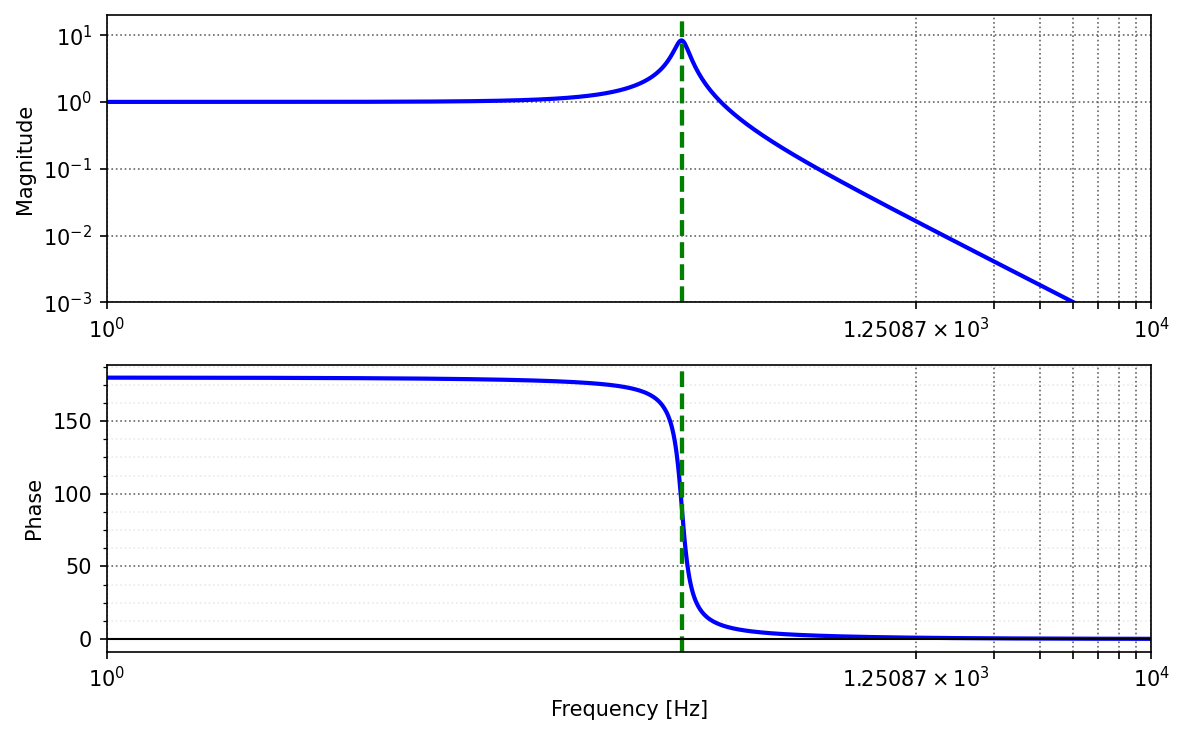

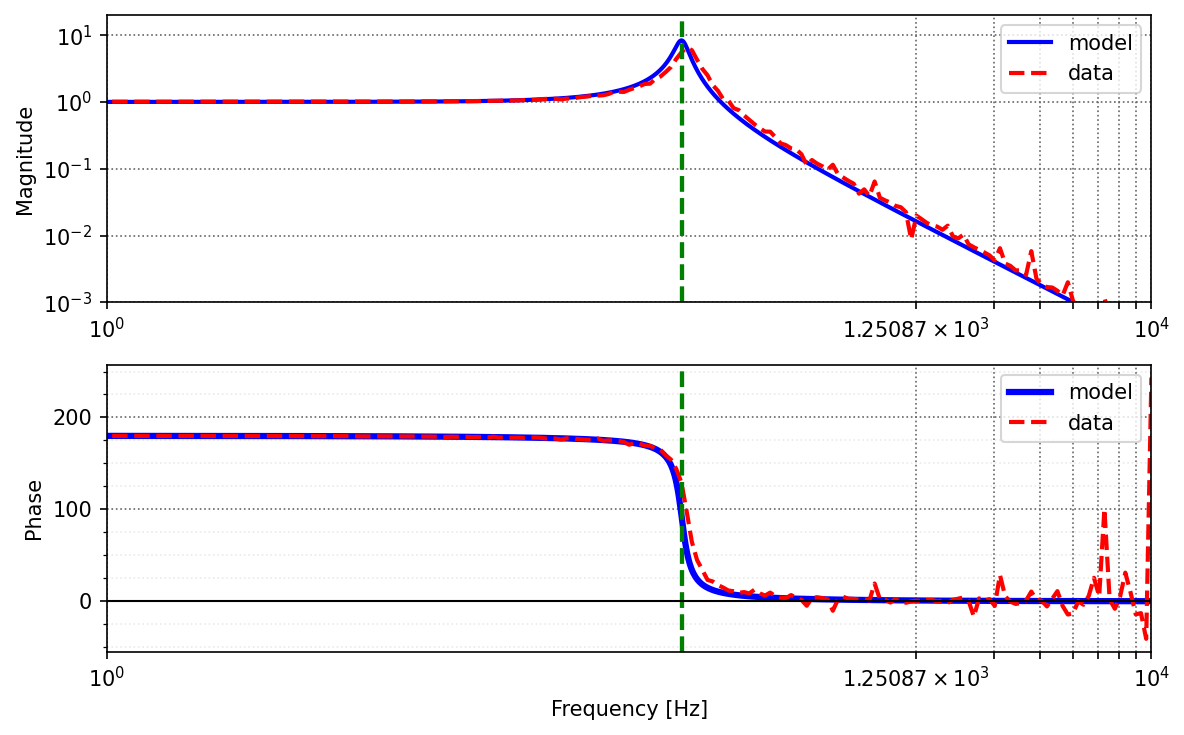

In [52]:
fv = logspace(0, 4, 1000)
wv = fv*2*np.pi
Gf = G(complex(0,1)*wv)

fig, ax = plt.subplots(2,1,figsize=(8, 5),dpi=150)
ax[0].loglog(fv,np.abs(Gf),color='b',ls='-')
ax[1].semilogx(fv,np.angle(Gf)*r2d,color='b',ls='-')
ax[0].set_ylim([.001,20])
#ax[1].set_ylim([90,270])
ax[0].set_ylabel("Magnitude")
ax[1].set_ylabel("Phase")
ax[1].set_xlabel("Frequency [Hz]")
for ii in range(2):
    [ax[ii].axvline(x=np.abs(p/2/np.pi),c='g',ls='--') for p in np.abs(G.poles())]
    [ax[ii].axvline(x=np.abs(z/2/np.pi),c='c',ls='--') for z in np.abs(G.zeros())]
nicegrid(ax)
savefig('figs/Active_resonant.pdf',dpi=600)

import read_csv_data
data = read_csv_data.Read_csv_data("data/Active_Resonant.csv")

fig, ax = plt.subplots(2,1,figsize=(8, 5),dpi=150)
ax[0].loglog(fv,np.abs(Gf),color='b',ls='-',label='model')
ax[0].loglog(data[:,0],10**(data[:,1]/20),color='r',ls='--',label='data')
ax[1].semilogx(fv,np.angle(Gf)*r2d,color='b',ls='-',lw=3,label='model')
ax[1].semilogx(data[:,0],data[:,2],color='r',ls='--',label='data')
ax[0].set_ylim([.001,20])
#ax[1].set_ylim([135,225])
ax[0].set_ylabel("Magnitude")
ax[1].set_ylabel("Phase")
ax[1].set_xlabel("Frequency [Hz]")
for ii in range(2):
    [ax[ii].axvline(x=np.abs(p/2/np.pi),c='g',ls='--') for p in np.abs(G.poles())]
    [ax[ii].axvline(x=np.abs(z/2/np.pi),c='c',ls='--') for z in np.abs(G.zeros())]
nicegrid(ax)
ax[0].legend()
ax[1].legend()
savefig('figs/Active_resonant_with_data.pdf',dpi=600)


In [53]:
a.Pi.transfer('Po').limit('Ad', oo)

                             -R₃                             
─────────────────────────────────────────────────────────────
                2                                            
C₁⋅C₂⋅R₁⋅R₂⋅R₃⋅s  + C₂⋅R₁⋅R₂⋅s + C₂⋅R₁⋅R₃⋅s + C₂⋅R₂⋅R₃⋅s + R₁

In [54]:
wd = G.poles()[0].imag
wn = np.abs(G.poles()[0])
zeta = -G.poles()[0].real/wn
print("zeta,wn,wd "+', '.join('{:>8.3f}'.format(i) for i in [zeta, wn/2/np.pi, wd, wn*np.sqrt(1-zeta**2)]))

zeta,wn,wd    0.060,  159.155,  998.198,  998.198


In [55]:
G.poles()[0].real/wn

In [56]:
CC1 = 1e-6
CC2 = 1e-9
R1 = 100e3
R2 = 10e3
R3 = 100e3
print('   alpha     beta      zeta      wn')
for alp in [0.1,1,10]:
    C1 = alp*CC1
    for beta in [0.1,1,10]:
        C2 = beta*CC2
        wn = np.sqrt(1/(C1*C2*R2*R3))
        zeta = (R1*R2 + R2*R3 + R1*R3)/(C1*R1*R2*R3)/2./wn
        print(""+', '.join('{:>8.3f}'.format(i) for i in [alp,beta,zeta,wn/2/np.pi]))

   alpha     beta      zeta      wn
   0.100,    0.100,    0.060, 1591.549
   0.100,    1.000,    0.190,  503.292
   0.100,   10.000,    0.600,  159.155
   1.000,    0.100,    0.019,  503.292
   1.000,    1.000,    0.060,  159.155
   1.000,   10.000,    0.190,   50.329
  10.000,    0.100,    0.006,  159.155
  10.000,    1.000,    0.019,   50.329
  10.000,   10.000,    0.060,   15.915


In [57]:
wn/2/np.pi

In [58]:
np.abs(G.poles()[0])/2/np.pi

# Resonant Dynamics - noninverting?

Distance conflict 0.5 vs 1.0 in vertical graph for Wanon4 between nodes (4, 92, 2) and (2_8, 3_8), due to incompatible sizes


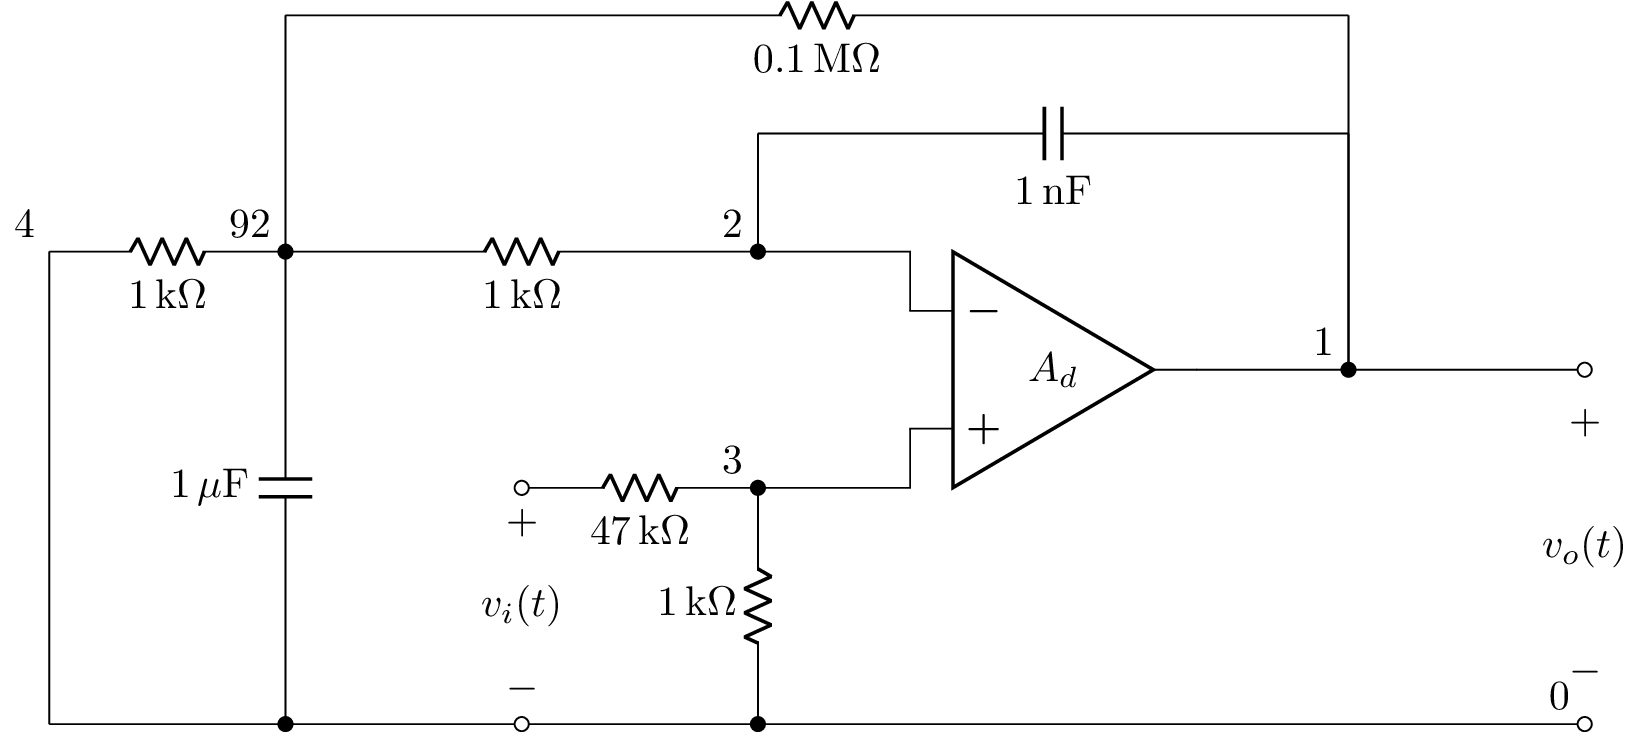

                2                                                          
C₁⋅C₂⋅R₁⋅R₂⋅R₃⋅s  + R₁ + R₃ + s⋅(C₁⋅R₁⋅R₃ + C₂⋅R₁⋅R₂ + C₂⋅R₁⋅R₃ + C₂⋅R₂⋅R₃)
───────────────────────────────────────────────────────────────────────────
        ⎛                2                                            ⎞    
     48⋅⎝C₁⋅C₂⋅R₁⋅R₂⋅R₃⋅s  + C₂⋅R₁⋅R₂⋅s + C₂⋅R₁⋅R₃⋅s + C₂⋅R₂⋅R₃⋅s + R₁⎠    

In [59]:
a = Circuit("""
E 1 0 opamp 3 2 Ad; right, flipud, scale=0.5
R1 4 92; right, scale=0.5
W 4 0_4; down
R2 92 2; right, scale=0.5
W 92 2_2; up=1
R3 2_2 1_1; right, scale=0.5
W 1_1 1; down
#
W 2 2_8; up=1
C2 2_8 3_8;right, scale=0.5
W 3_8 1;down
#
R77 2_55 3 47e3; right, scale=0.5
R7 3 0_3 1e3; down, scale=0.5
Pi 2_55 0_25; down, v^=v_i(t)
W 1 1_2; right
Po 1_2 0; down, v^=v_o(t)
W 0_4 0_92; right
W 0_92 0_25; right
W 0_25 0_3; right
W 0_3 0; right
C1 92 0_92; down, scale=0.5
; draw_nodes=connections, label_ids=none, label_nodes=primary
""")
cct10 = a.subs({'R1': 1000, 'R2': 1e3, 'R3': 100e3, 'C1': 1*1e-6, 'C2': 1e-9})
#cct10 = a.subs({'R1': 4700, 'R2': 4700, 'R3': 4700, 'C1': 1e-7, 'C2': 1e-8})
cct10.draw()
a.Pi.transfer('Po').limit('Ad', oo)

In [60]:
from sympy import sqrt, simplify, N
RR = a.Pi.transfer('Po').limit('Ad', oo)
hh = RR.as_N_D()[1]
hhh = hh.coeffs()
wn = (hhh[2]/hhh[0])**(0.5)
print(wn)
zeta = ((hhh[1]/hhh[0])/2/wn).limit('R1', oo)
zeta

1/(sqrt(C1)*sqrt(C2)*sqrt(R2)*sqrt(R3))


     48⋅C₂⋅R₂ + 48⋅C₂⋅R₃      
──────────────────────────────
     ____   ____   ____   ____
96⋅╲╱ C₁ ⋅╲╱ C₂ ⋅╲╱ R₂ ⋅╲╱ R₃ 

In [61]:
Hl = cct10.Pi.transfer('Po').limit('Ad', oo)
Num,Den = N(Hl).as_N_D()
NN = [Num.coeffs()[x].fval for x in range(len(Num.coeffs()))]
DD = [Den.coeffs()[x].fval for x in range(len(Den.coeffs()))]

G = tf(np.real(NN),np.real(DD))
print("Poles = "+', '.join('{:6.2f}'.format(x/2/np.pi) for x in G.poles()))
print("Zeros = "+', '.join('{:6.2f}'.format(x/2/np.pi) for x in G.zeros()))

G

Poles = -159.95+477.20j, -159.95-477.20j
Zeros = -159314.26+0.00j, -160.59+0.00j


TransferFunction(array([   0.021,  20875.208,  21041666.667]), array([   1.000,  2010.000,  10000000.000]))

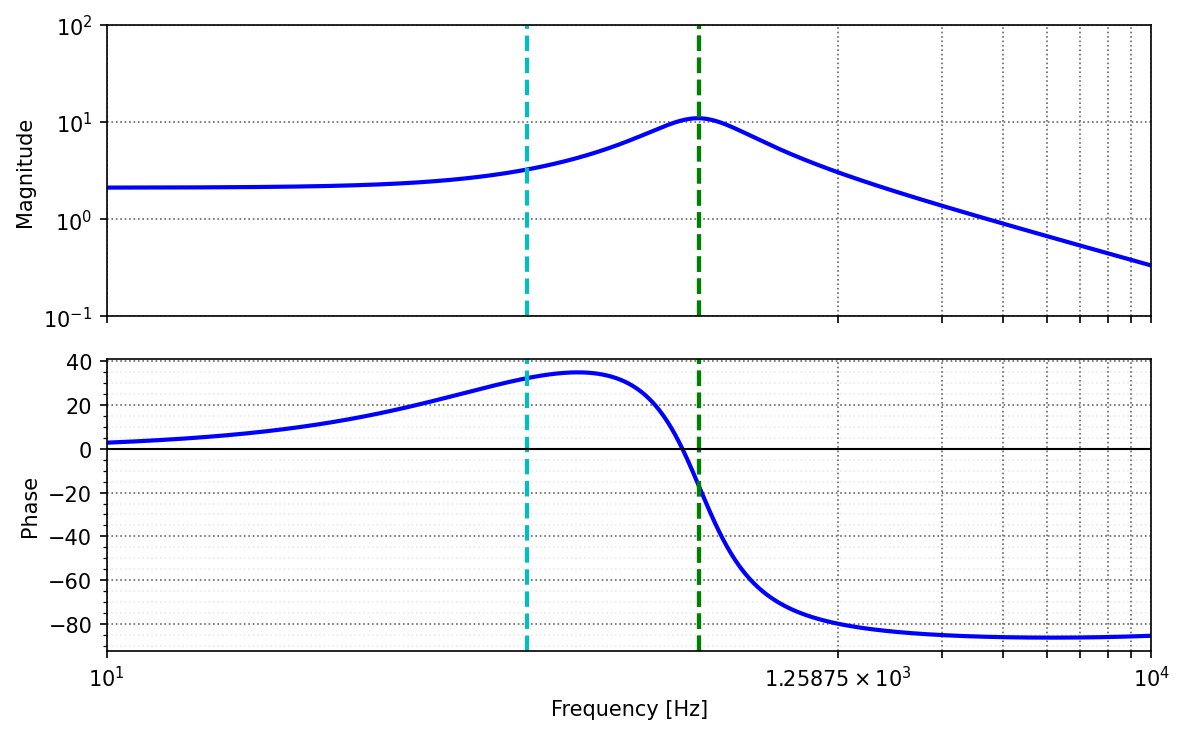

In [62]:
fv = logspace(1, 4, 1000)
wv = fv*2*np.pi
Gf = G(complex(0,1)*wv)

fig, ax = plt.subplots(2,1,figsize=(8, 5),dpi=150,sharex=True)
ax[0].loglog(fv,np.abs(Gf),color='b',ls='-')
ax[1].semilogx(fv,np.angle(Gf)*r2d,color='b',ls='-')
ax[0].set_xlim([10,1e4])
ax[0].set_ylim([.1,100])
#ax[1].set_ylim([90,270])
ax[0].set_ylabel("Magnitude")
ax[1].set_ylabel("Phase")
ax[1].set_xlabel("Frequency [Hz]")
for ii in range(2):
    [ax[ii].axvline(x=np.abs(p/2/np.pi),c='g',ls='--') for p in np.abs(G.poles())]
    [ax[ii].axvline(x=np.abs(z/2/np.pi),c='c',ls='--') for z in np.abs(G.zeros())]
nicegrid(ax)
#savefig('figs/Active_resonant.pdf',dpi=600)


In [63]:
a.Pi.transfer('Po').limit('Ad', oo).limit(s, 0)

R₁ + R₃
───────
 48⋅R₁ 

In [64]:
wd = G.poles()[0].imag
wn = np.abs(G.poles()[0])
zeta = -G.poles()[0].real/wn
print("zeta,wn,wd "+', '.join('{:>8.3f}'.format(i) for i in [zeta, wn/2/np.pi, wd, wn*np.sqrt(1-zeta**2)]))

zeta,wn,wd    0.318,  503.292, 2998.329, 2998.329


In [65]:
G.poles()[0].real/wn

In [66]:
CC1 = 1e-6
CC2 = 1e-9
R1 = 100e3
R2 = 10e3
R3 = 100e3
print('   alpha     beta      zeta      wn')
for alp in [0.1,1,10]:
    C1 = alp*CC1
    for beta in [0.1,1,10]:
        C2 = beta*CC2
        wn = np.sqrt(1/(C1*C2*R2*R3))
        zeta = (R1*R2 + R2*R3 + R1*R3)/(C1*R1*R2*R3)/2./wn
        print(""+', '.join('{:>8.3f}'.format(i) for i in [alp,beta,zeta,wn/2/np.pi]))

   alpha     beta      zeta      wn
   0.100,    0.100,    0.060, 1591.549
   0.100,    1.000,    0.190,  503.292
   0.100,   10.000,    0.600,  159.155
   1.000,    0.100,    0.019,  503.292
   1.000,    1.000,    0.060,  159.155
   1.000,   10.000,    0.190,   50.329
  10.000,    0.100,    0.006,  159.155
  10.000,    1.000,    0.019,   50.329
  10.000,   10.000,    0.060,   15.915


In [67]:
wn/2/np.pi

In [68]:
np.abs(G.poles()[0])/2/np.pi

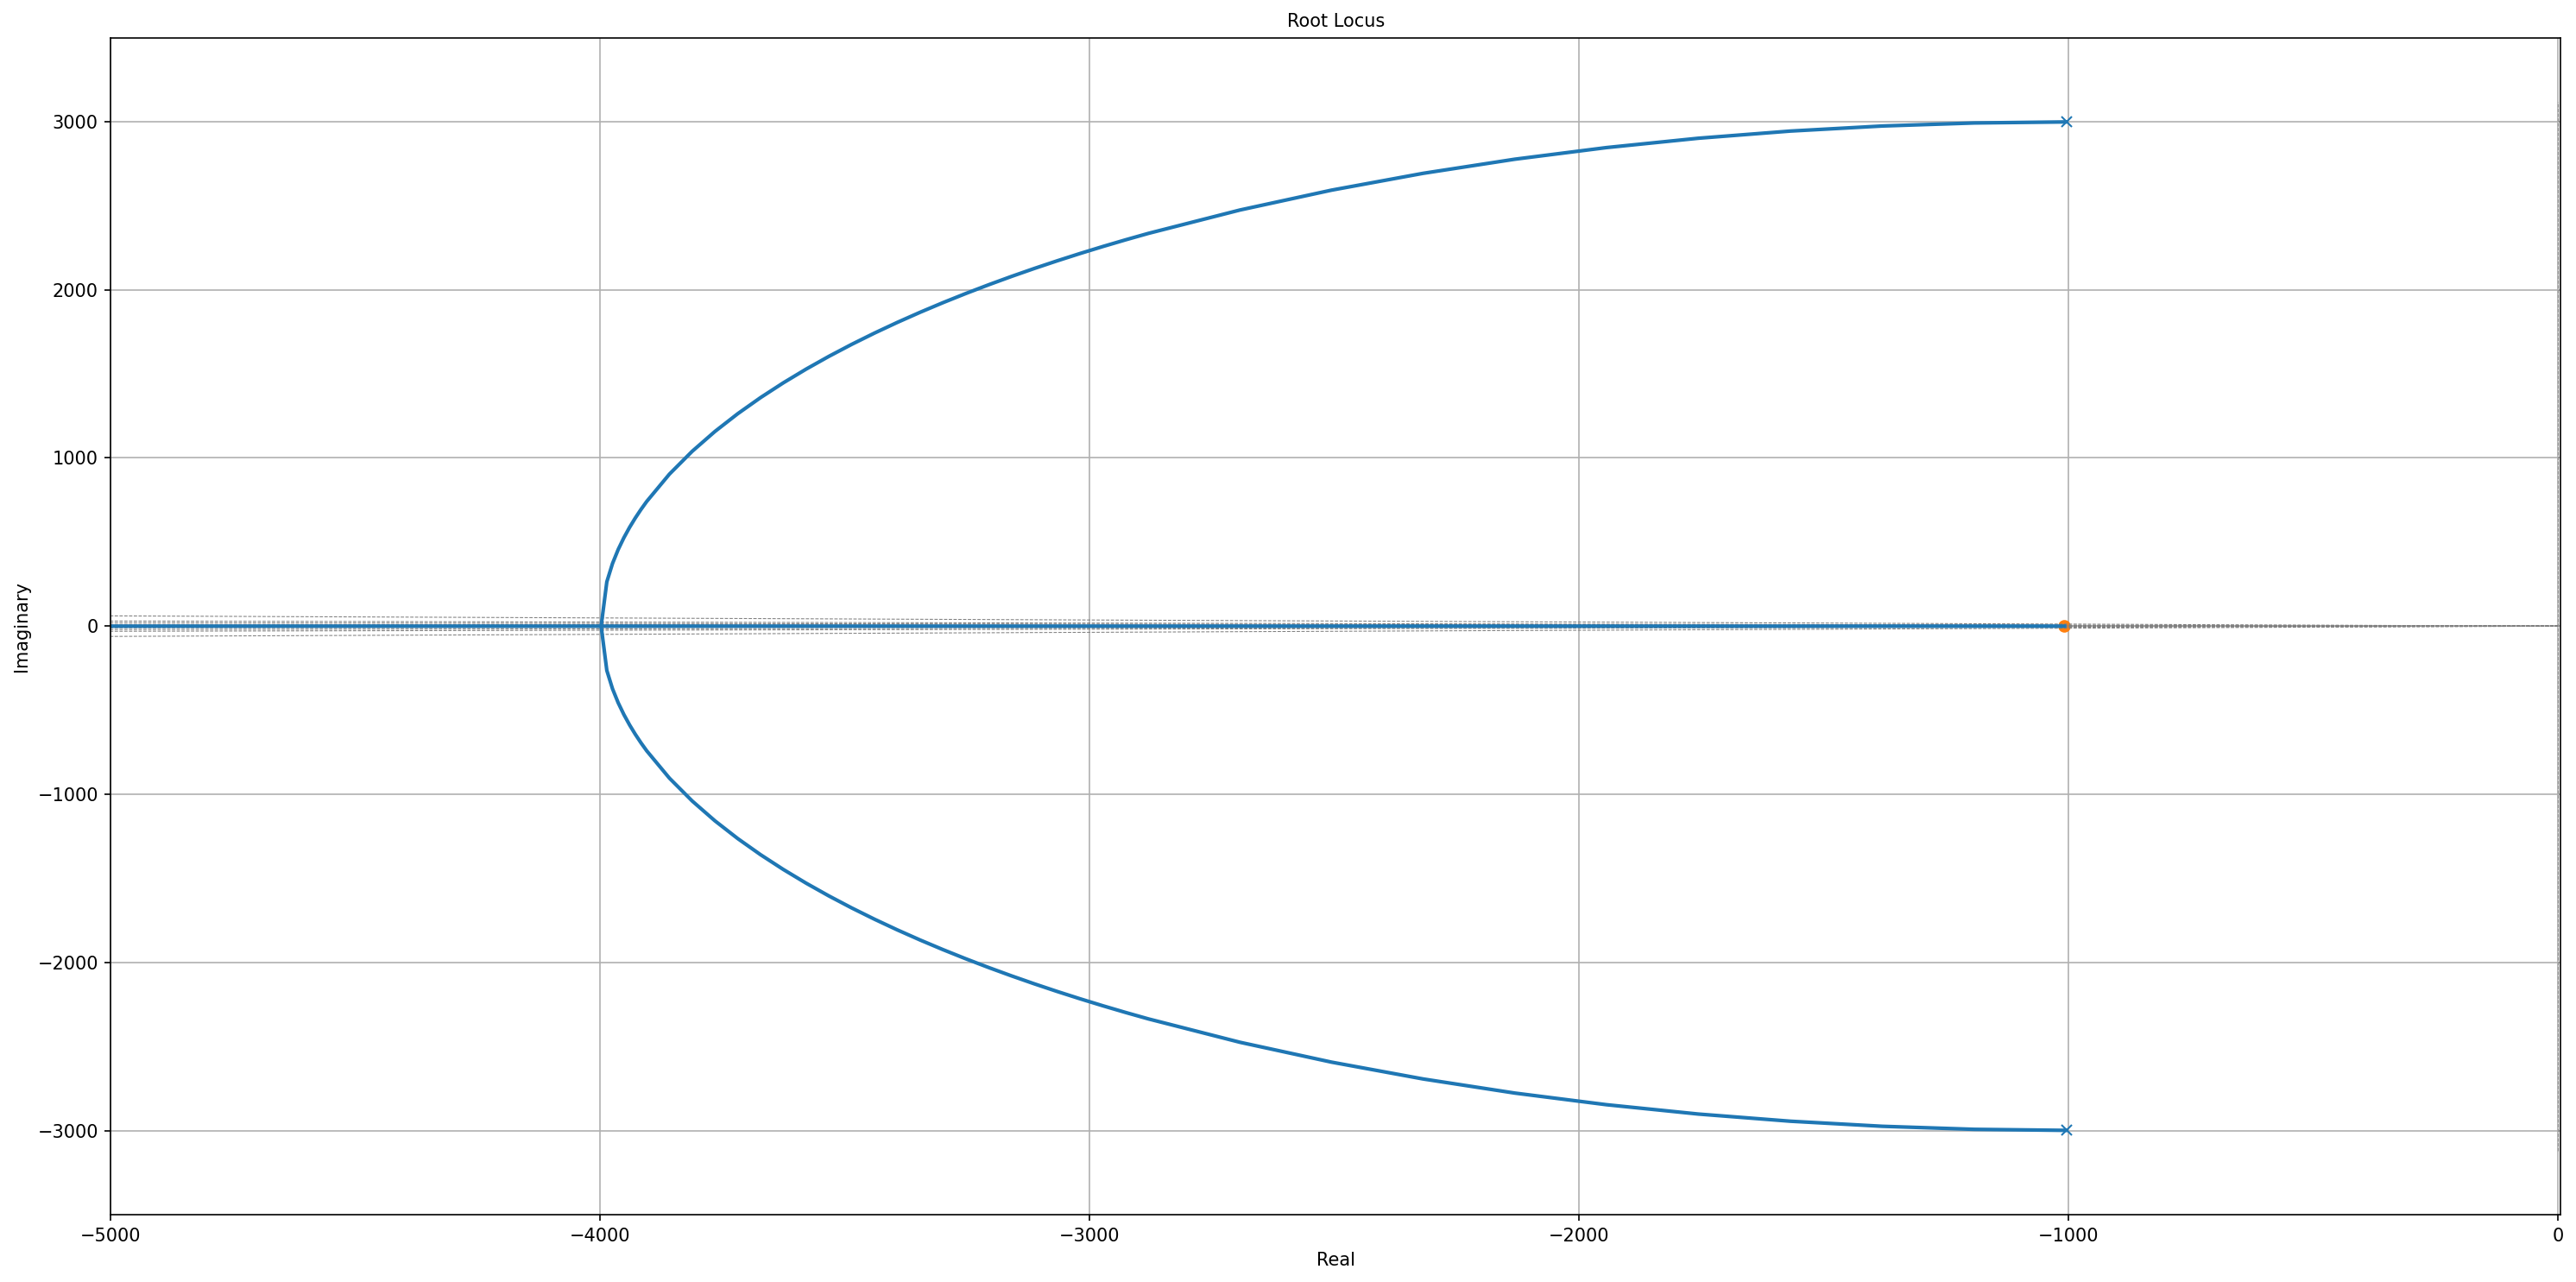

In [69]:
rlocus(G)
plt.xlim([-5000,5])
plt.ylim([-3500,3500])